# 사용할 코드만 정리

In [1]:
# 도구 불러오기
import pandas as pd
import numpy as np
import glob
import os
import re
import ast
from glob import glob
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.font_manager as fm

# 판다스 출력 제한 해제 
pd.set_option('display.max_rows', 100) # 최대 100행까지 생략 없이 출력
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', 1000)

In [2]:
# 원본 메타데이터 로드
df_meta = pd.read_csv("../../dataset/metadata.csv")

In [3]:
# 전처리 (시간/수치형(Capacity, Re, Rct)/file_num 파생)

def clean_parse_time(x):
    if pd.isna(x):
        return pd.NaT
    
    try:
        s = str(x)
        pattern = r"[-+]?\d*\.?\d+[eE][-+]?\d+|[-+]?\d+\.?\d*"
        parts = re.findall(pattern, s)
        
        if len(parts) < 3:
            return pd.NaT
        
        nums = [float(p) for p in parts]
        
        year   = int(nums[0])
        month  = int(nums[1])
        day    = int(nums[2])
        hour   = int(nums[3]) if len(nums) > 3 else 0
        minute = int(nums[4]) if len(nums) > 4 else 0
        
        # 핵심: round 제거
        second = int(nums[5]) if len(nums) > 5 else 0
        
        return pd.Timestamp(year=year, month=month, day=day,
                            hour=hour, minute=minute, second=second)
    
    except Exception as e:
        print(f"[파싱 실패] {x} | {e}")
        return pd.NaT

def clean_numeric(x):
    """수치형 데이터의 대괄호 제거 및 float 변환"""
    if pd.isna(x): return np.nan
    val = str(x).replace('[', '').replace(']', '').strip()
    try:
        return float(val)
    except:
        return np.nan

# --- [전처리 실행] ---
df = df_meta.copy()

# 1. 시간 데이터 정제 (소수점 초까지 완벽 대응)
df['start_time'] = df['start_time'].apply(clean_parse_time)

# 2. 수치형 데이터 정제 (Capacity, Re, Rct)
for col in ['Capacity', 'Re', 'Rct']:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)

# 3. 물리적 순서 정렬 (파일 번호 기준)
df['file_num'] = df['filename'].str.extract(r'(\d+)').astype(int)
df = df.sort_values(['battery_id', 'file_num']).reset_index(drop=True)

# 최종 결과 검증
print(f"전체 데이터 개수: {len(df):,}개")
print(f"시간 결측치(NaT): {df['start_time'].isna().sum()}개")
print(f"수치형 결측치(Cap): {df['Capacity'].isna().sum()}개")


전체 데이터 개수: 7,565개
시간 결측치(NaT): 0개
수치형 결측치(Cap): 4796개


In [4]:
df

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,file_num
0,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,5121
1,discharge,2008-04-02 15:25:41,24,B0005,1,5122,05122.csv,1.856487,NaN,NaN,5122
2,charge,2008-04-02 16:37:51,24,B0005,2,5123,05123.csv,NaN,NaN,NaN,5123
3,discharge,2008-04-02 19:43:48,24,B0005,3,5124,05124.csv,1.846327,NaN,NaN,5124
4,charge,2008-04-02 20:55:40,24,B0005,4,5125,05125.csv,NaN,NaN,NaN,5125
...,...,...,...,...,...,...,...,...,...,...,...
7560,impedance,2010-09-30 07:36:45,24,B0056,247,7309,07309.csv,NaN,0.102677,0.170394,7309
7561,discharge,2010-09-30 08:08:36,4,B0056,248,7310,07310.csv,1.137273,NaN,NaN,7310
7562,charge,2010-09-30 08:48:54,4,B0056,249,7311,07311.csv,NaN,NaN,NaN,7311
7563,discharge,2010-09-30 11:50:17,4,B0056,250,7312,07312.csv,1.129059,NaN,NaN,7312


# metadata df에서 B0005만 필터링

In [5]:
#####
# metadata df에서 B0005만 필터링하여 시간순 정렬

# 판다스 출력 옵션 설정 (최대 행/열 제한 해제)
pd.set_option('display.max_rows', None)  # 모든 행 출력
pd.set_option('display.max_columns', None)  # 모든 열 출력
pd.set_option('display.width', None)  # 줄바꿈 없이 출력
pd.set_option('display.max_colwidth', None) # 컬럼 내용 생략 없이 출력

# 생성
B0005_timeline = df[df['battery_id'] == 'B0005'].copy()

# 시간순 정렬 후 주요 컬럼만 출력
# 'type', 'start_time', 'cycle'을 중심으로 나열
check_cols = ['type', 'start_time','test_id', 'filename', 'Capacity','Re','Rct']
display(B0005_timeline[check_cols].sort_values('start_time'))

# 출력이 끝난 후 옵션을 다시 기본값으로 되돌리고 싶다면 (선택사항)
# pd.reset_option('all')

,type,start_time,test_id,filename,Capacity,Re,Rct
0,charge,2008-04-02 13:08:17,0,05121.csv,NaN,NaN,NaN
1,discharge,2008-04-02 15:25:41,1,05122.csv,1.856487,NaN,NaN
2,charge,2008-04-02 16:37:51,2,05123.csv,NaN,NaN,NaN
3,discharge,2008-04-02 19:43:48,3,05124.csv,1.846327,NaN,NaN
4,charge,2008-04-02 20:55:40,4,05125.csv,NaN,NaN,NaN
5,discharge,2008-04-03 00:01:06,5,05126.csv,1.835349,NaN,NaN
6,charge,2008-04-03 01:12:38,6,05127.csv,NaN,NaN,NaN
7,discharge,2008-04-03 04:16:37,7,05128.csv,1.835263,NaN,NaN
8,charge,2008-04-03 05:27:49,8,05129.csv,NaN,NaN,NaN
9,discharge,2008-04-03 08:33:25,9,05130.csv,1.834646,NaN,NaN


# B0005_timeline의 메타정보를 data들을 가져와서 병합

In [63]:
import pandas as pd
import numpy as np
import os

# 1. 설정 및 타임라인 준비
target_id = 'B0005'
data_folder = "../../dataset/data" 

# [수정] 원본 타임라인 데이터프레임을 B0005_timeline으로 정의하고 인덱스를 컬럼으로 추출
B0005_timeline = df[df['battery_id'] == target_id].sort_values('start_time').copy()
# 인덱스를 'total_cycle' 컬럼으로 변환 (1부터 시작하도록 설정)
B0005_timeline['total_cycle'] = range(1, len(B0005_timeline) + 1)

# 2. EOL 계산 (RUL 산출용)
dis_only = B0005_timeline[B0005_timeline['type'] == 'discharge']
first_cap = dis_only['Capacity'].iloc[0] if not dis_only.empty else 0
eol_idx = np.where((dis_only['Capacity'] / first_cap) * 100 <= 80)[0]
eol_cycle_num = eol_idx[0] + 1 if len(eol_idx) > 0 else np.nan

# 3. 통합 저장소 및 카운터
all_data_list = []
counters = {'charge': 1, 'discharge': 1, 'impedance': 1}
discharge_cycle_counter = 0

# 4. 루프 및 조인 (B0005_timeline 기준)
for _, row in B0005_timeline.iterrows():
    file_path = os.path.join(data_folder, row['filename'])
    
    if os.path.exists(file_path):
        # CSV 로드
        temp_df = pd.read_csv(file_path)
        d_type = row['type']
        
        # (A) 타임라인의 모든 메타데이터 주입 (total_cycle 포함)
        for col in B0005_timeline.columns:
            temp_df[col] = row[col]
        
        # (B) 타입별 내부 회차 (cycle_in_type)
        temp_df['cycle_in_type'] = counters[d_type]
        
        # (C) 방전 기준 사이클 (discharge_cycle)
        if d_type == 'discharge':
            discharge_cycle_counter += 1
        temp_df['discharge_cycle'] = discharge_cycle_counter
        
        # (D) SOH & (E) RUL
        temp_df['SOH_target'] = (row['Capacity'] / first_cap * 100) if d_type == 'discharge' else np.nan
        if pd.notnull(eol_cycle_num):
            temp_df['RUL'] = max(0, eol_cycle_num - discharge_cycle_counter)
        else:
            temp_df['RUL'] = np.nan
        
        all_data_list.append(temp_df)
        
        # 카운터 업데이트
        counters[d_type] += 1

# 5. 최종 합치기
df_total_B0005 = pd.concat(all_data_list, ignore_index=True)

# 6. 시간순 정렬 및 결측치 처리
df_total_B0005['start_time'] = pd.to_datetime(df_total_B0005['start_time'])
df_total_B0005 = df_total_B0005.sort_values(['start_time', 'Time'])

# SOH_target ffill/bfill
df_total_B0005['SOH_target'] = df_total_B0005['SOH_target'].ffill().bfill()

print(f"✅ 통합 완료! B0005_timeline의 인덱스가 'total_cycle'로 반영되었습니다.")
print(f"포함된 컬럼: {df_total_B0005.columns.tolist()}")

✅ 통합 완료! B0005_timeline의 인덱스가 'total_cycle'로 반영되었습니다.
포함된 컬럼: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time', 'type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'file_num', 'total_cycle', 'cycle_in_type', 'discharge_cycle', 'SOH_target', 'RUL', 'Current_load', 'Voltage_load', 'Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance']


In [64]:
df_total_B0005.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,file_num,total_cycle,cycle_in_type,discharge_cycle,SOH_target,RUL,Current_load,Voltage_load,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance
0,3.873017,-0.001201,24.655358,0.000,0.003,0.000,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,5121,1,1,0,100.0,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.479394,-4.030268,24.666480,-4.036,1.570,2.532,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,5121,1,1,0,100.0,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.000588,1.512731,24.675394,1.500,4.726,5.500,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,5121,1,1,0,100.0,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.012395,1.509063,24.693865,1.500,4.742,8.344,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,5121,1,1,0,100.0,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.019708,1.511318,24.705069,1.500,4.753,11.125,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,5121,1,1,0,100.0,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
display(df_total_B0005.describe())
print(df_total_B0005.shape)
print(df_total_B0005.info())

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,start_time,ambient_temperature,test_id,uid,Capacity,Re,Rct,file_num,total_cycle,cycle_in_type,discharge_cycle,SOH_target,RUL,Current_load,Voltage_load
count,591458.000000,591458.000000,591458.000000,541173.000000,541173.000000,591458.000000,604802,604802.0,604802.000000,604802.000000,50285.000000,13344.000000,13344.000000,604802.000000,604802.000000,604802.000000,604802.000000,604802.000000,604802.000000,50285.000000,50285.000000
mean,4.103945,0.369404,26.369701,0.566810,4.184427,4763.856934,2008-05-09 02:27:19.284465408,24.0,329.104173,5450.104173,1.560345,0.054245,0.077340,5450.104173,330.104173,96.847753,93.692898,82.900104,22.372239,1.362700,2.308406
min,0.003365,-4.479660,23.214802,-4.468000,0.003000,0.000000,2008-04-02 13:08:17,24.0,0.000000,5121.000000,1.287453,0.043559,0.064883,5121.000000,1.000000,1.000000,0.000000,69.348842,0.000000,-1.998400,0.000000
25%,4.089426,0.040636,24.488485,0.057000,4.250000,1928.175750,2008-05-01 14:41:41,24.0,191.000000,5312.000000,1.386229,0.049159,0.071464,5312.000000,192.000000,61.000000,58.000000,74.077335,0.000000,1.998000,2.388000
50%,4.205140,0.171961,25.479630,0.225000,4.332000,4467.515500,2008-05-10 16:11:56,24.0,331.000000,5452.000000,1.538237,0.055850,0.077487,5452.000000,332.000000,97.000000,95.000000,81.711154,6.000000,1.998200,2.533000
75%,4.205908,1.259778,27.348768,1.498000,4.688000,7503.824000,2008-05-18 23:53:33,24.0,474.000000,5595.000000,1.746871,0.058820,0.082576,5595.000000,475.000000,134.000000,131.000000,91.894751,43.000000,1.998200,2.690000
max,8.393141,1.531301,41.450232,1.500000,5.002000,10807.328000,2008-05-28 11:09:42,24.0,615.000000,5736.000000,1.856487,0.063516,0.089757,5736.000000,616.000000,278.000000,168.000000,100.000000,101.000000,1.998400,4.238000
std,0.213469,0.907558,2.772424,0.616015,1.112792,3147.859026,NaN,0.0,165.738729,165.738729,0.182380,0.005480,0.006356,165.738729,165.738729,44.653158,43.250104,9.454393,27.523776,1.313698,0.800300


(604802, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604802 entries, 0 to 604801
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Voltage_measured      591458 non-null  float64       
 1   Current_measured      591458 non-null  float64       
 2   Temperature_measured  591458 non-null  float64       
 3   Current_charge        541173 non-null  float64       
 4   Voltage_charge        541173 non-null  float64       
 5   Time                  591458 non-null  float64       
 6   type                  604802 non-null  object        
 7   start_time            604802 non-null  datetime64[ns]
 8   ambient_temperature   604802 non-null  int64         
 9   battery_id            604802 non-null  object        
 10  test_id               604802 non-null  int64         
 11  uid                   604802 non-null  int64         
 12  filename              604802 non-null  object

In [66]:
df_c= df_total_B0005[df_total_B0005['type'] == 'charge']
display(df_c.describe())
print(df_c.shape)
print(df_c.info())

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,start_time,ambient_temperature,test_id,uid,Capacity,Re,Rct,file_num,total_cycle,cycle_in_type,discharge_cycle,SOH_target,RUL,Current_load,Voltage_load
count,541173.000000,541173.000000,541173.000000,541173.000000,541173.000000,541173.000000,541173,541173.0,541173.000000,541173.000000,0.0,0.0,0.0,541173.000000,541173.000000,541173.000000,541173.000000,541173.000000,541173.000000,0.0,0.0
mean,4.158644,0.571543,25.770628,0.566810,4.184427,5062.836059,2008-05-09 06:46:20.295431936,24.0,331.271553,5452.271553,NaN,NaN,NaN,5452.271553,332.271553,96.606471,94.221402,82.788695,21.969804,NaN,NaN
min,0.003365,-4.479660,23.246728,-4.468000,0.003000,0.000000,2008-04-02 13:08:17,24.0,0.000000,5121.000000,NaN,NaN,NaN,5121.000000,1.000000,1.000000,0.000000,69.348842,0.000000,NaN,NaN
25%,4.195473,0.058024,24.438659,0.057000,4.250000,2271.610000,2008-05-01 19:38:17,24.0,195.000000,5316.000000,NaN,NaN,NaN,5316.000000,196.000000,62.000000,59.000000,74.077335,0.000000,NaN,NaN
50%,4.205310,0.227544,25.255235,0.225000,4.332000,4982.078000,2008-05-10 17:36:13,24.0,333.000000,5454.000000,NaN,NaN,NaN,5454.000000,334.000000,97.000000,95.000000,81.711154,6.000000,NaN,NaN
75%,4.205978,1.506508,26.819807,1.498000,4.688000,7763.219000,2008-05-18 23:53:33,24.0,474.000000,5595.000000,NaN,NaN,NaN,5595.000000,475.000000,133.000000,131.000000,91.587533,42.000000,NaN,NaN
max,8.393141,1.531301,31.187718,1.500000,5.002000,10807.328000,2008-05-28 11:09:42,24.0,615.000000,5736.000000,NaN,NaN,NaN,5736.000000,616.000000,170.000000,168.000000,100.000000,101.000000,NaN,NaN
std,0.098078,0.620454,1.643729,0.616015,1.112792,3114.798871,NaN,0.0,164.749267,164.749267,NaN,NaN,NaN,164.749267,164.749267,42.702483,42.985171,9.407978,27.209508,NaN,NaN


(541173, 29)
<class 'pandas.core.frame.DataFrame'>
Index: 541173 entries, 0 to 604801
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Voltage_measured      541173 non-null  float64       
 1   Current_measured      541173 non-null  float64       
 2   Temperature_measured  541173 non-null  float64       
 3   Current_charge        541173 non-null  float64       
 4   Voltage_charge        541173 non-null  float64       
 5   Time                  541173 non-null  float64       
 6   type                  541173 non-null  object        
 7   start_time            541173 non-null  datetime64[ns]
 8   ambient_temperature   541173 non-null  int64         
 9   battery_id            541173 non-null  object        
 10  test_id               541173 non-null  int64         
 11  uid                   541173 non-null  int64         
 12  filename              541173 non-null  object     

In [67]:
df_d = df_total_B0005[df_total_B0005['type'] == 'discharge']
display(df_d.describe())
print(df_d.shape)
print(df_d.info())

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,start_time,ambient_temperature,test_id,uid,Capacity,Re,Rct,file_num,total_cycle,cycle_in_type,discharge_cycle,SOH_target,RUL,Current_load,Voltage_load
count,50285.000000,50285.000000,50285.000000,0.0,0.0,50285.000000,50285,50285.0,50285.000000,50285.000000,50285.000000,0.0,0.0,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000
mean,3.515268,-1.806032,32.816991,NaN,NaN,1546.208924,2008-05-07 01:58:43.570826240,24.0,306.374187,5427.374187,1.560345,NaN,NaN,5427.374187,307.374187,88.125942,88.125942,84.048225,26.630248,1.362700,2.308406
min,2.455679,-2.029098,23.214802,NaN,NaN,0.000000,2008-04-02 15:25:41,24.0,1.000000,5122.000000,1.287453,NaN,NaN,5122.000000,2.000000,1.000000,1.000000,69.348842,0.000000,-1.998400,0.000000
25%,3.399384,-2.013415,30.019392,NaN,NaN,768.563000,2008-04-29 22:00:04,24.0,157.000000,5278.000000,1.386229,NaN,NaN,5278.000000,158.000000,50.000000,50.000000,74.669440,0.000000,1.998000,2.388000
50%,3.511664,-2.012312,32.828944,NaN,NaN,1537.031000,2008-05-07 21:56:09,24.0,305.000000,5426.000000,1.538237,NaN,NaN,5426.000000,306.000000,88.000000,88.000000,82.857367,13.000000,1.998200,2.533000
75%,3.660903,-2.011052,35.920887,NaN,NaN,2305.984000,2008-05-18 03:05:19,24.0,456.000000,5577.000000,1.746871,NaN,NaN,5577.000000,457.000000,127.000000,127.000000,94.095473,51.000000,1.998200,2.690000
max,4.222920,0.007496,41.450232,NaN,NaN,3690.234000,2008-05-27 20:45:42,24.0,613.000000,5734.000000,1.856487,NaN,NaN,5734.000000,614.000000,168.000000,168.000000,100.000000,100.000000,1.998400,4.238000
std,0.231778,0.610502,3.987515,NaN,NaN,906.640295,NaN,0.0,174.371083,174.371083,0.182380,NaN,NaN,174.371083,174.371083,45.699687,45.699687,9.823903,30.490488,1.313698,0.800300


(50285, 29)
<class 'pandas.core.frame.DataFrame'>
Index: 50285 entries, 789 to 604748
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Voltage_measured      50285 non-null  float64       
 1   Current_measured      50285 non-null  float64       
 2   Temperature_measured  50285 non-null  float64       
 3   Current_charge        0 non-null      float64       
 4   Voltage_charge        0 non-null      float64       
 5   Time                  50285 non-null  float64       
 6   type                  50285 non-null  object        
 7   start_time            50285 non-null  datetime64[ns]
 8   ambient_temperature   50285 non-null  int64         
 9   battery_id            50285 non-null  object        
 10  test_id               50285 non-null  int64         
 11  uid                   50285 non-null  int64         
 12  filename              50285 non-null  object        
 13  Capaci

In [68]:
df_i = df_total_B0005[df_total_B0005['type'] == 'impedance']
print(df_i.shape)
display(df_i.describe())
print(df_i.info())

(13344, 29)


,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,start_time,ambient_temperature,test_id,uid,Capacity,Re,Rct,file_num,total_cycle,cycle_in_type,discharge_cycle,SOH_target,RUL,Current_load,Voltage_load
count,0.0,0.0,0.0,0.0,0.0,0.0,13344,13344.0,13344.000000,13344.000000,0.0,13344.000000,13344.000000,13344.000000,13344.000000,13344.000000,13344.000000,13344.000000,13344.000000,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,2008-05-09 10:03:23.428057600,24.0,326.859712,5447.859712,NaN,0.054245,0.077340,5447.859712,327.859712,139.500000,93.237410,83.091826,22.647482,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18 20:55:29,24.0,40.000000,5161.000000,NaN,0.043559,0.064883,5161.000000,41.000000,1.000000,19.000000,69.348842,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2008-05-01 07:44:12,24.0,184.000000,5305.000000,NaN,0.049159,0.071464,5305.000000,185.000000,70.000000,56.000000,73.822897,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2008-05-10 11:26:19.500000,24.0,327.000000,5448.000000,NaN,0.055850,0.077487,5448.000000,328.000000,139.500000,93.500000,81.878640,7.500000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2008-05-18 18:26:10,24.0,469.000000,5590.000000,NaN,0.058820,0.082576,5590.000000,470.000000,209.000000,130.000000,92.422201,45.000000,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2008-05-27 21:34:28,24.0,614.000000,5735.000000,NaN,0.063516,0.089757,5735.000000,615.000000,278.000000,168.000000,99.747649,82.000000,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,165.919642,165.919642,NaN,0.005480,0.006356,165.919642,165.919642,80.254175,42.988489,9.620527,27.050492,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 13344 entries, 22900 to 604796
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Voltage_measured      0 non-null      float64       
 1   Current_measured      0 non-null      float64       
 2   Temperature_measured  0 non-null      float64       
 3   Current_charge        0 non-null      float64       
 4   Voltage_charge        0 non-null      float64       
 5   Time                  0 non-null      float64       
 6   type                  13344 non-null  object        
 7   start_time            13344 non-null  datetime64[ns]
 8   ambient_temperature   13344 non-null  int64         
 9   battery_id            13344 non-null  object        
 10  test_id               13344 non-null  int64         
 11  uid                   13344 non-null  int64         
 12  filename              13344 non-null  object        
 13  Capacity        

# 방전시간과 방전시작시간~임피던스 시간이 일치하는지 확인하기

In [ ]:
# 중요 지우면안됨 1번 데이터준비!!

# 1. 기초 데이터 준비
df = B0005_timeline.copy()
df['start_time'] = pd.to_datetime(df['start_time'])

# 2. 타입별 데이터 분리
chg_all = df[df['type'] == 'charge'][['total_cycle', 'start_time']].sort_values('start_time')
imp_all = df[df['type'] == 'impedance'][['total_cycle', 'start_time']].sort_values('start_time')
dis_all = df[df['type'] == 'discharge'][['total_cycle', 'start_time', 'Capacity']].sort_values('start_time')

# [핵심 수정] 40번 사이클(2008-04-18 17:34:22)부터 루프를 시작하도록 chg_all 필터링
# 혹은 chg_all = chg_all[chg_all['total_cycle'] >= 40] 도 가능합니다.
chg_target = chg_all[chg_all['start_time'] >= pd.Timestamp('2008-04-18 17:34:22')]

# 3. 루프를 이용한 엄격한 시퀀스 추출
extracted_rows = []
for _, chg in chg_target.iterrows():
    # 현재 충전 이후의 첫 번째 임피던스
    imp1 = imp_all[imp_all['start_time'] > chg['start_time']].head(1)
    if imp1.empty: continue
    
    # 임피던스1 이후의 첫 번째 방전
    dis = dis_all[dis_all['start_time'] > imp1.iloc[0]['start_time']].head(1)
    if dis.empty: continue
    
    # 방전 이후의 첫 번째 임피던스2
    imp2 = imp_all[imp_all['start_time'] > dis.iloc[0]['start_time']].head(1)
    if imp2.empty: continue
    
    # 순서 검증
    if not (chg['total_cycle'] <= imp1.iloc[0]['total_cycle'] <= dis.iloc[0]['total_cycle'] <= imp2.iloc[0]['total_cycle']):
        continue

    extracted_rows.append({
        'chg_t_cycle': chg['total_cycle'], 'chg_start': chg['start_time'],
        'imp_t_cycle': imp1.iloc[0]['total_cycle'], 'imp_start': imp1.iloc[0]['start_time'],
        'dis_t_cycle': dis.iloc[0]['total_cycle'], 'dis_start': dis.iloc[0]['start_time'],
        'imp2_t_cycle': imp2.iloc[0]['total_cycle'], 'imp2_start': imp2.iloc[0]['start_time']
    })

# 4. 데이터프레임 변환 및 정리
final_result = pd.DataFrame(extracted_rows)
final_result = final_result.drop_duplicates(subset=['imp_start'], keep='first')
final_result = final_result.drop_duplicates(subset=['dis_start'], keep='first')
final_result = final_result.drop_duplicates(subset=['imp2_start'], keep='first').reset_index(drop=True)

# 5. Gap 계산
final_result['chg_imp_gap'] = (final_result['imp_start'] - final_result['chg_start']).dt.total_seconds()
final_result['imp_dis_gap'] = (final_result['dis_start'] - final_result['imp_start']).dt.total_seconds()
final_result['next_chg_start'] = final_result['chg_start'].shift(-1)
final_result['imp2_next_chg_gap'] = (final_result['next_chg_start'] - final_result['imp2_start']).dt.total_seconds()

# 사이클 번호 정수화
cycle_cols = ['chg_t_cycle', 'imp_t_cycle', 'dis_t_cycle', 'imp2_t_cycle']
final_result[cycle_cols] = final_result[cycle_cols].astype(int)

# 6. 결과 확인
display(final_result[['chg_t_cycle', 'chg_start', 'imp_t_cycle', 'imp_start', 'dis_t_cycle', 'dis_start', 'imp2_t_cycle', 'imp2_start', 'imp2_next_chg_gap']].head(10))


,chg_t_cycle,chg_start,imp_t_cycle,imp_start,dis_t_cycle,dis_start,imp2_t_cycle,imp2_start,imp2_next_chg_gap
0,40,2008-04-18 17:34:22,41,2008-04-18 20:55:29,42,2008-04-18 21:10:19,43,2008-04-18 22:39:16,882.0
1,44,2008-04-18 22:53:58,45,2008-04-19 02:14:27,46,2008-04-19 02:29:09,47,2008-04-19 03:57:24,882.0
2,48,2008-04-19 04:12:06,49,2008-04-19 07:32:33,50,2008-04-19 07:47:15,51,2008-04-19 09:15:10,882.0
3,52,2008-04-19 09:29:52,53,2008-04-19 12:47:00,54,2008-04-19 13:01:42,55,2008-04-19 14:28:58,883.0
4,56,2008-04-19 14:43:41,57,2008-04-19 18:12:47,58,2008-04-19 18:27:29,59,2008-04-19 19:55:05,882.0
5,60,2008-04-19 20:09:47,61,2008-04-19 23:27:13,62,2008-04-19 23:41:55,63,2008-04-20 01:08:11,882.0
6,64,2008-04-20 01:22:53,65,2008-04-20 04:39:59,66,2008-04-20 04:54:41,67,2008-04-20 06:20:57,882.0
7,68,2008-04-20 06:35:39,69,2008-04-20 10:01:46,70,2008-04-20 10:16:28,71,2008-04-20 11:42:26,882.0
8,72,2008-04-20 11:57:08,73,2008-04-20 15:22:22,74,2008-04-20 15:37:05,75,2008-04-20 17:03:01,883.0
9,76,2008-04-20 17:17:44,77,2008-04-20 20:35:56,78,2008-04-20 20:50:38,79,2008-04-20 22:16:35,883.0


In [133]:
#두번째로 빠르게 이거해보라함

# B0005_timeline으로 시트 구성해서 df_battery_B0005??인가를 매핑하라함

# 이건 시행착오였음
# charge에서 start_time+time에서의 time, 거기서부터 ~ 그다음 start_time 이 제일 가까운 impedance까지의 시간, 그로부터 가장가까운 discharge까지의 시간, discharge의 time, max(time)으로부터 가장가까운 start_time의 impedance까지의 시간, 그로부터 가장가까운 charge까지의 시간
# chg_cycle, chg_duration, imp_cycle, chg_imp, imp_dis, dis_cycle, dis_duration
# chg_cycle (charge의 cycle 번호 그대로), chg_start_time, chg_duration, imp_cycle(impedance의 cycle 번호 그대로), imp_start_time, chg_imp, imp_dis, dis_cycle(didscharge의 cycle 번호 그대로), charge_start_time, dis_duration
# chg_cycle (df_total_B0005의 type : charge의 cycle 번호 그대로), chg_start_time, chg_duration, imp_cycle(df_total_B0005의 impedance의 cycle 번호 그대로), imp_start_time, chg_imp, imp_dis, dis_cycle(df_total_B0005의 didscharge의 cycle 번호 그대로), charge_start_time, dis_duration
# 중요한건 모든행이 아니라, cycle당 1개로 해야함

# 생성 규칙
# 1. start_time이 최우선이다. 2. ___t_cycle의 숫자가 다음index 에 있을 ___t_cycle 숫자보다 작으면 안된다. 
# 3. cycle당 1개로 해야함 4. 행의 구성은 다음과 같다. chg_t_cycle chg_cycle chg_start_time chg_duration imp_t_cycle imp_cycle imp_start_time chg_imp imp_dis dis_t_cycle dis_cycle dis_start_time dis_duration  imp2_t_cycle imp2_cycle imp2_start_time imp2_dis
# 5. chg_t_cycle(해당cha의 df_total_B0005의 total_cycle 그대로), chg_cycle (df_total_B0005의 type : charge의 cycle 번호 그대로), chg_start_time, chg_duration, imp_t_cycle(해당imp의 df_total_B0005의 total_cycle 그대로), imp_cycle(df_total_B0005의 impedance의 cycle 번호 그대로), imp_start_time, chg_imp, imp_dis, dis_t_cycle(해당dis의 df_total_B0005의 total_cycle 그대로), dis_cycle(df_total_B0005의 didscharge의 cycle 번호 그대로), charge_start_time, dis_duration, (discharge의 start_time+time이후로 가까운 impedance의 start_time을 가진 imp2) imp2_t_cycle(해당imp2의 df_total_B0005의 total_cycle 그대로), imp2_cycle(df_total_B0005의 impedance2의 cycle 번호 그대로), imp2_start_time(해당imp2의 start_time), imp2_dis((해당imp2의 start_time과 가장가까운 dis의 start_time에서 해당imp2의 start_time뺀 시간====해당dis는 다음index의 dis와 같을 수 있다고 허용)


import pandas as pd

# 1. 기초 데이터 준비
df_total = df_total_B0005.copy()
df_total['start_time'] = pd.to_datetime(df_total['start_time'])

# 2. 타입별 데이터 분리 및 컬럼명 미리 변경 (KeyError 방지)
chg = df_total[df_total['type'] == 'charge'][['total_cycle', 'discharge_cycle', 'start_time', 'Time']].sort_values('start_time')
chg.columns = ['chg_t_cycle', 'chg_cycle', 'chg_start_time', 'chg_duration']

# [추가된 핵심 코드] 40번 사이클(2008-04-18 17:34:22) 이후 데이터만 남기기
chg = chg[chg['chg_start_time'] >= pd.Timestamp('2008-04-18 17:34:22')]

imp = df_total[df_total['type'] == 'impedance'][['total_cycle', 'discharge_cycle', 'start_time']].sort_values('start_time')
imp.columns = ['imp_t_cycle', 'imp_cycle', 'imp_start_time']

dis = df_total[df_total['type'] == 'discharge'][['total_cycle', 'discharge_cycle', 'start_time', 'Time']].sort_values('start_time')
dis.columns = ['dis_t_cycle', 'dis_cycle', 'dis_start_time', 'dis_duration']

# 3. 고속 병합 (merge_asof)
# Step 1: Charge -> Impedance 1
final = pd.merge_asof(
    chg, imp, left_on='chg_start_time', right_on='imp_start_time', direction='forward'
).dropna(subset=['imp_start_time'])

# Step 2: Impedance 1 -> Discharge
final = pd.merge_asof(
    final, dis, left_on='imp_start_time', right_on='dis_start_time', direction='forward'
).dropna(subset=['dis_start_time'])

# Step 3: Discharge -> Impedance 2
imp2 = imp.copy()
imp2.columns = ['imp2_t_cycle', 'imp2_cycle', 'imp2_start_time']

final = pd.merge_asof(
    final, imp2, left_on='dis_start_time', right_on='imp2_start_time', direction='forward'
).dropna(subset=['imp2_start_time'])

# 4. 중복 데이터 제거 (물리적 시퀀스 보장)
final = final.drop_duplicates(subset=['imp_start_time'], keep='first')
final = final.drop_duplicates(subset=['dis_start_time'], keep='first')
final = final.drop_duplicates(subset=['imp2_start_time'], keep='first').reset_index(drop=True)

# 5. 시간 간격(Gap) 계산
final['chg_imp'] = (final['imp_start_time'] - final['chg_start_time']).dt.total_seconds()
final['imp_dis'] = (final['dis_start_time'] - final['imp_start_time']).dt.total_seconds()

# imp2_dis: 현재 imp2_start부터 "다음 행"의 chg_start_time까지의 간격
final['next_chg_start'] = final['chg_start_time'].shift(-1)
final['imp2_dis'] = (final['next_chg_start'] - final['imp2_start_time']).dt.total_seconds()

# 6. 최종 컬럼 순서 조정
result_cols = [
    'chg_t_cycle', 'chg_cycle', 'chg_start_time', 'chg_duration',
    'imp_t_cycle', 'imp_cycle', 'imp_start_time', 'chg_imp', 'imp_dis',
    'dis_t_cycle', 'dis_cycle', 'dis_start_time', 'dis_duration',
    'imp2_t_cycle', 'imp2_cycle', 'imp2_start_time', 'imp2_dis'
]

final_output = final[result_cols].copy()

# float로 되어 있는 사이클 컬럼들을 찾아서 정수형으로 변환
cycle_cols = [col for col in final_output.columns if 'cycle' in col]

for col in cycle_cols:
    # NaN이 있을 경우 0으로 채우고 정수로 변환
    final_output[col] = final_output[col].fillna(0).astype(int)

# 결과 출력
display(final_output)

,chg_t_cycle,chg_cycle,chg_start_time,chg_duration,imp_t_cycle,imp_cycle,imp_start_time,chg_imp,imp_dis,dis_t_cycle,dis_cycle,dis_start_time,dis_duration,imp2_t_cycle,imp2_cycle,imp2_start_time,imp2_dis
0,40,19,2008-04-18 17:34:22,4796.359,41,19,2008-04-18 20:55:29,12067.0,890.0,42,20,2008-04-18 21:10:19,2400.828,43,20,2008-04-18 22:39:16,882.0
1,44,20,2008-04-18 22:53:58,4771.281,45,20,2008-04-19 02:14:27,12029.0,882.0,46,21,2008-04-19 02:29:09,2211.641,47,21,2008-04-19 03:57:24,882.0
2,48,21,2008-04-19 04:12:06,4802.468,49,21,2008-04-19 07:32:33,12027.0,882.0,50,22,2008-04-19 07:47:15,2345.313,51,22,2008-04-19 09:15:10,882.0
3,52,22,2008-04-19 09:29:52,4675.062,53,22,2008-04-19 12:47:00,11828.0,882.0,54,23,2008-04-19 13:01:42,2344.235,55,23,2008-04-19 14:28:58,883.0
4,56,23,2008-04-19 14:43:41,4995.078,57,23,2008-04-19 18:12:47,12546.0,882.0,58,24,2008-04-19 18:27:29,2324.922,59,24,2008-04-19 19:55:05,882.0
5,60,24,2008-04-19 20:09:47,4686.609,61,24,2008-04-19 23:27:13,11846.0,882.0,62,25,2008-04-19 23:41:55,2268.547,63,25,2008-04-20 01:08:11,882.0
6,64,25,2008-04-20 01:22:53,4703.828,65,25,2008-04-20 04:39:59,11826.0,882.0,66,26,2008-04-20 04:54:41,2286.329,67,26,2008-04-20 06:20:57,882.0
7,68,26,2008-04-20 06:35:39,4940.000,69,26,2008-04-20 10:01:46,12367.0,882.0,70,27,2008-04-20 10:16:28,2287.609,71,27,2008-04-20 11:42:26,882.0
8,72,27,2008-04-20 11:57:08,4922.641,73,27,2008-04-20 15:22:22,12314.0,883.0,74,28,2008-04-20 15:37:05,2267.484,75,28,2008-04-20 17:03:01,883.0
9,76,28,2008-04-20 17:17:44,4705.828,77,28,2008-04-20 20:35:56,11892.0,882.0,78,29,2008-04-20 20:50:38,2248.172,79,29,2008-04-20 22:16:35,883.0


In [ ]:
final_output.info() # 형변환이전에 찍어봄

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   chg_t_cycle      136 non-null    int64         
 1   chg_cycle        136 non-null    int64         
 2   chg_start_time   136 non-null    datetime64[ns]
 3   chg_duration     136 non-null    float64       
 4   imp_t_cycle      136 non-null    float64       
 5   imp_cycle        136 non-null    float64       
 6   imp_start_time   136 non-null    datetime64[ns]
 7   chg_imp          136 non-null    float64       
 8   imp_dis          136 non-null    float64       
 9   dis_t_cycle      136 non-null    float64       
 10  dis_cycle        136 non-null    float64       
 11  dis_start_time   136 non-null    datetime64[ns]
 12  dis_duration     136 non-null    float64       
 13  imp2_t_cycle     136 non-null    int64         
 14  imp2_cycle       136 non-null    int64    

In [128]:
final_output.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   chg_t_cycle      136 non-null    int64         
 1   chg_cycle        136 non-null    int64         
 2   chg_start_time   136 non-null    datetime64[ns]
 3   chg_duration     136 non-null    float64       
 4   imp_t_cycle      136 non-null    int64         
 5   imp_cycle        136 non-null    int64         
 6   imp_start_time   136 non-null    datetime64[ns]
 7   chg_imp          136 non-null    float64       
 8   imp_dis          136 non-null    float64       
 9   dis_t_cycle      136 non-null    int64         
 10  dis_cycle        136 non-null    int64         
 11  dis_start_time   136 non-null    datetime64[ns]
 12  dis_duration     136 non-null    float64       
 13  imp2_t_cycle     136 non-null    int64         
 14  imp2_cycle       136 non-null    int64    

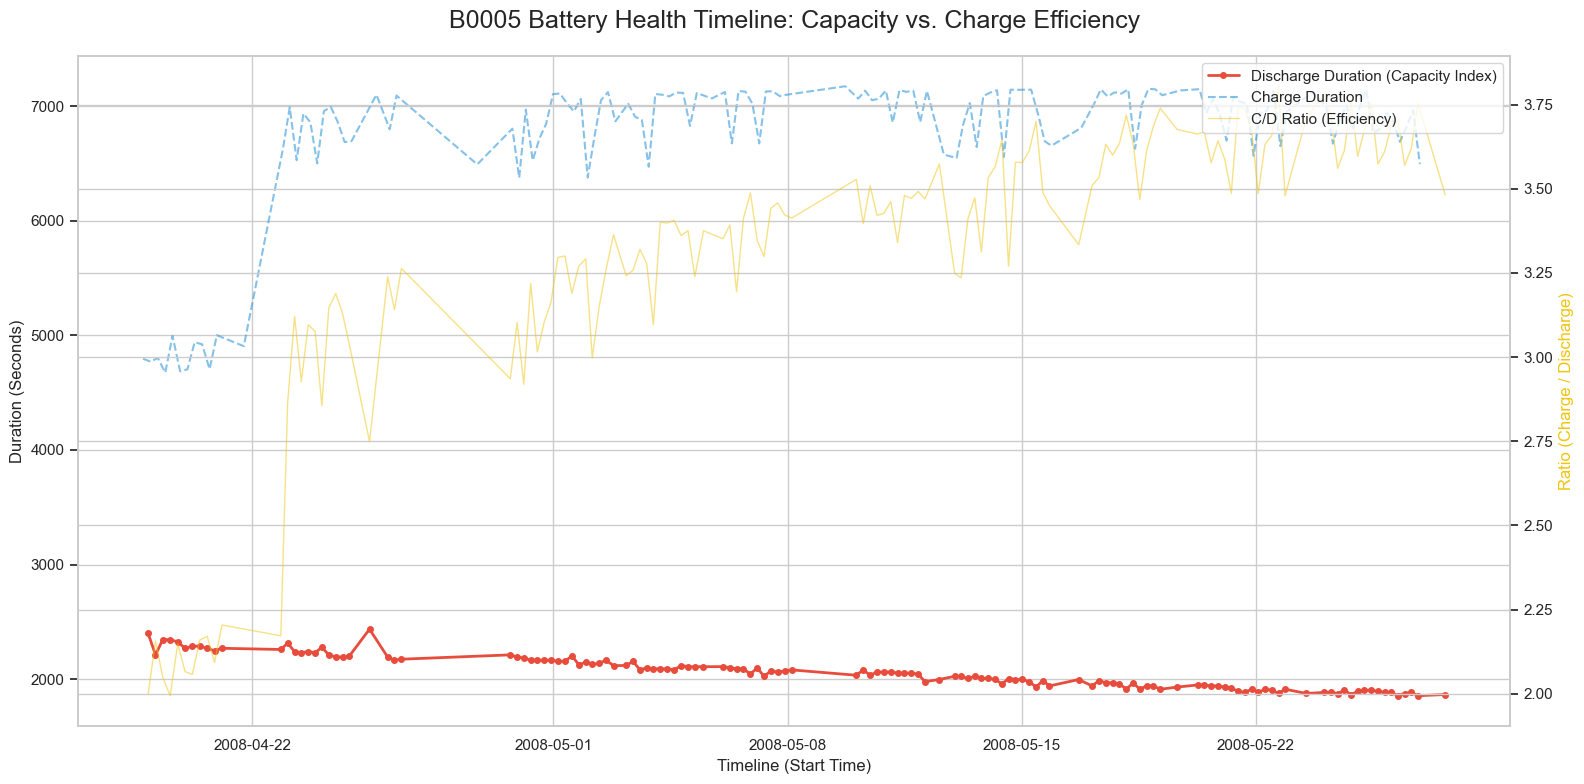

In [129]:
# 1. 충전 vs 방전 지속 시간 (Efficiency & SOH)
# 2. 방전 시간 대비 충전 시간의 비율 (C/D Ratio)
# chg_duration / dis_duration 비율을 계산해 보세요. 배터리가 건강할 때는 이 비율이 일정하다가, 수명 종료(EOL) 시점에 가까워질수록 이 균형이 깨짐
# 비율이 급격히 변하는 지점이 바로 배터리의 성질이 변하는 'Critical Point'

# 1. 스타일 설정
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(16, 8))

# 2. 첫 번째 축: 방전 및 충전 시간 (절대적인 성능 지표)
ax1.plot(final_output['dis_start_time'], final_output['dis_duration'], 
         label='Discharge Duration (Capacity Index)', color='#e74c3c', marker='o', markersize=4, linewidth=2)
ax1.plot(final_output['chg_start_time'], final_output['chg_duration'], 
         label='Charge Duration', color='#3498db', alpha=0.6, linestyle='--')

ax1.set_xlabel('Timeline (Start Time)', fontsize=12)
ax1.set_ylabel('Duration (Seconds)', fontsize=12)
ax1.tick_params(axis='y')

# 3. 두 번째 축 (TwinX): 충전/방전 비율 (Efficiency Index)
# 배터리가 노후화될수록 적게 담기고(방전 짧아짐) 충전 양상은 변하므로 이 비율이 중요합니다.
ax2 = ax1.twinx()
cd_ratio = final_output['chg_duration'] / final_output['dis_duration']
ax2.plot(final_output['dis_start_time'], cd_ratio, 
         label='C/D Ratio (Efficiency)', color='#f1c40f', linewidth=1, alpha=0.5)
ax2.set_ylabel('Ratio (Charge / Discharge)', fontsize=12, color='#f1c40f')

# 4. 마무리
plt.title('B0005 Battery Health Timeline: Capacity vs. Charge Efficiency', fontsize=18, pad=20)
fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 절대 시간 흐름에 따른 '점진적 열화' 확인


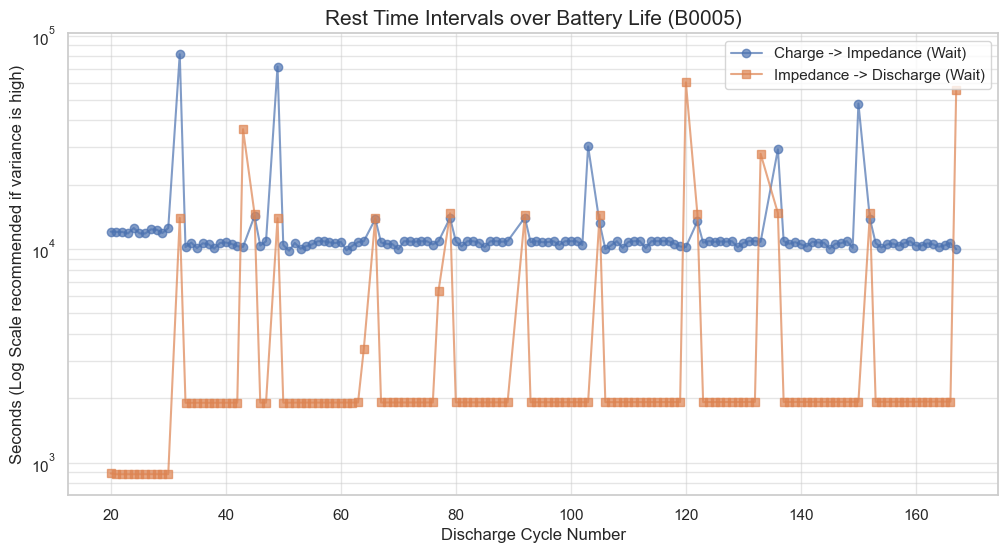

In [130]:
# 시각화 : 배터리 수명 흐름도

plt.figure(figsize=(12, 6))

# X축을 방전 사이클 번호로 설정
plt.plot(final_output['dis_cycle'], final_output['chg_imp'], label='Charge -> Impedance (Wait)', marker='o', alpha=0.7)
plt.plot(final_output['dis_cycle'], final_output['imp_dis'], label='Impedance -> Discharge (Wait)', marker='s', alpha=0.7)

plt.title('Rest Time Intervals over Battery Life (B0005)', fontsize=15)
plt.xlabel('Discharge Cycle Number')
plt.ylabel('Seconds (Log Scale recommended if variance is high)')
plt.yscale('log') # 간격 차이가 크면 로그 스케일이 보기 좋습니다.
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

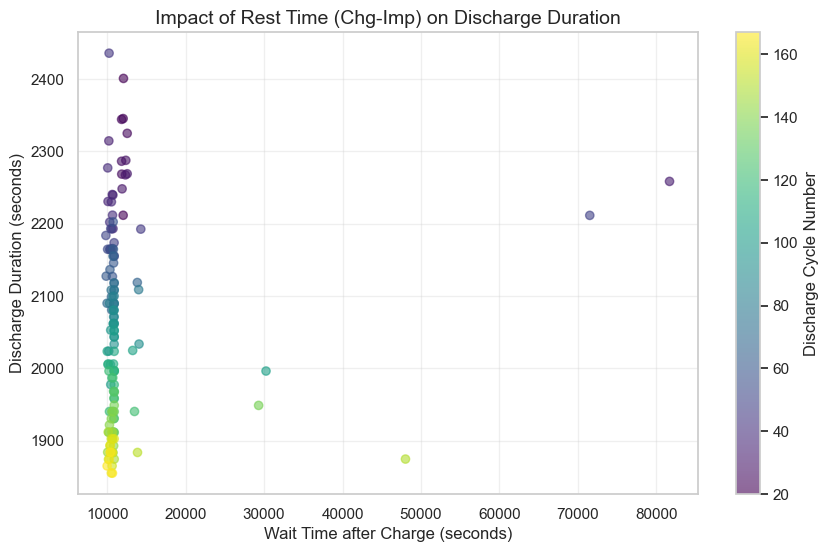

In [131]:
# 시각화 : 방전 시간(Capacity 대용치)과 휴지 시간의 상관관계

plt.figure(figsize=(10, 6))

# 데이터의 흐름(사이클)을 색상(hue)으로 표현하여 열화 진행도를 같이 봅니다.
scatter = plt.scatter(final_output['chg_imp'], final_output['dis_duration'], 
                      c=final_output['dis_cycle'], cmap='viridis', alpha=0.6)

plt.colorbar(scatter, label='Discharge Cycle Number')
plt.title('Impact of Rest Time (Chg-Imp) on Discharge Duration', fontsize=14)
plt.xlabel('Wait Time after Charge (seconds)')
plt.ylabel('Discharge Duration (seconds)')
plt.grid(True, alpha=0.3)
plt.show()

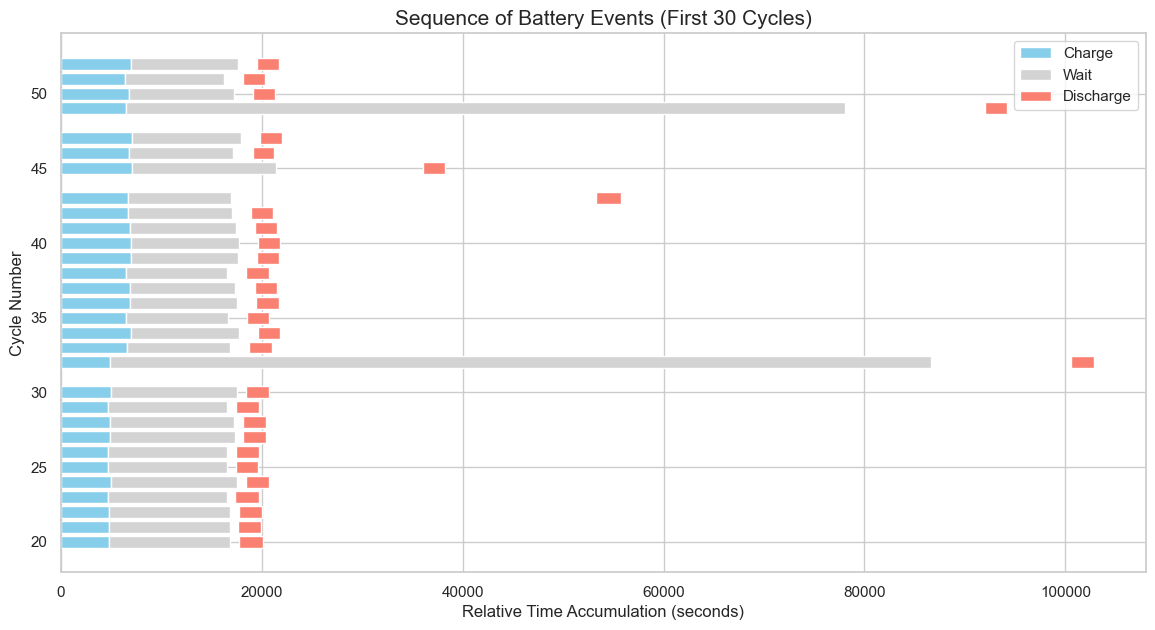

In [132]:
# 시각화 : 전체 실험 타임라인 요약 (Gantt Chart 스타일)


# 상위 30개 사이클만 샘플링해서 보기
sample = final_output.head(30)

fig, ax = plt.subplots(figsize=(14, 7))

for i, row in sample.iterrows():
    # 충전 지속 시간
    ax.barh(row['dis_cycle'], row['chg_duration'], left=0, color='skyblue', label='Charge' if i==0 else "")
    # 충전-임피던스 대기 시간
    ax.barh(row['dis_cycle'], row['chg_imp'], left=row['chg_duration'], color='lightgrey', label='Wait' if i==0 else "")
    # 방전 지속 시간 (시각화를 위해 임의 간격 조정 가능)
    ax.barh(row['dis_cycle'], row['dis_duration'], left=row['chg_duration'] + row['chg_imp'] + row['imp_dis'], 
            color='salmon', label='Discharge' if i==0 else "")

plt.title('Sequence of Battery Events (First 30 Cycles)', fontsize=15)
plt.xlabel('Relative Time Accumulation (seconds)')
plt.ylabel('Cycle Number')
plt.legend()
plt.show()

1
1

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1
1
# 여기까지 보고 아래는 하려다 말음 (혹시나 아래는 보지마세요 정리안된것임)

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1

In [62]:
import pandas as pd

# 1. 데이터 타입 변환 및 정렬
df_total_B0005['start_time'] = pd.to_datetime(df_total_B0005['start_time'])

# 2. 타입별 'cycle_in_type' 기준 대표 데이터 추출 (중복 제거)
# 각 타입 내의 고유 회차(cycle_in_type)당 가장 먼저 시작된 데이터 1개만 남깁니다.
def get_unique_type_cycle(df, t_type):
    subset = df[df['type'] == t_type].sort_values('start_time')
    # cycle_in_type 기준으로 그룹화하여 첫 번째 행만 추출
    return subset.groupby('cycle_in_type').first().reset_index()

chg_unique = get_unique_type_cycle(df_total_B0005, 'charge')
imp_unique = get_unique_type_cycle(df_total_B0005, 'impedance')
dis_unique = get_unique_type_cycle(df_total_B0005, 'discharge')

# 3. 컬럼명 정리 및 종료 시점 계산
chg_p = chg_unique[['cycle_in_type', 'start_time', 'Time']].rename(
    columns={'cycle_in_type': 'chg_cycle', 'start_time': 'chg_start_time', 'Time': 'chg_duration'}
)
chg_p['chg_end'] = chg_p['chg_start_time'] + pd.to_timedelta(chg_p['chg_duration'], unit='s')

imp_p = imp_unique[['cycle_in_type', 'start_time']].rename(
    columns={'cycle_in_type': 'imp_cycle', 'start_time': 'imp_start_time'}
)

dis_p = dis_unique[['cycle_in_type', 'start_time', 'Time']].rename(
    columns={'cycle_in_type': 'dis_cycle', 'start_time': 'dis_start_time', 'Time': 'dis_duration'}
)

# 4. [자석 매칭] 임피던스 시점을 기준으로 앞뒤 실험 결합
# 시간 순서상 임피던스 직전의 충전과 직후의 방전을 찾습니다.
final = pd.merge_asof(
    imp_p.sort_values('imp_start_time'),
    chg_p.sort_values('chg_end'),
    left_on='imp_start_time', right_on='chg_end',
    direction='backward'
)

final = pd.merge_asof(
    final.sort_values('imp_start_time'),
    dis_p.sort_values('dis_start_time'),
    left_on='imp_start_time', right_on='dis_start_time',
    direction='forward'
)

# 5. [사용자 정의 공식 연산]
# chg_imp = 임피던스 시작 - (충전 시작 + 충전 시간)
final['chg_imp'] = (final['imp_start_time'] - final['chg_end']).dt.total_seconds()

# imp_dis = 방전 시작 - 임피던스 시작
final['imp_dis'] = (final['dis_start_time'] - final['imp_start_time']).dt.total_seconds()

# 6. 최종 컬럼 구성 (요청하신 모든 컬럼 포함)
final_cols = [
    'chg_cycle', 'chg_start_time', 'chg_duration', 
    'imp_cycle', 'imp_start_time', 'chg_imp', 'imp_dis', 
    'dis_cycle', 'dis_start_time', 'dis_duration'
]

# 결과 정리 (NaN 제거 및 중복 방지)
final_result = final[final_cols].dropna(subset=['chg_cycle', 'dis_cycle']).reset_index(drop=True)
final_result[['chg_imp', 'imp_dis']] = final_result[['chg_imp', 'imp_dis']].clip(lower=0)

print(f"--- [완료] cycle_in_type 기반 {len(final_result)}개 세트 통합 ---")
display(final_result.head(20))

--- [완료] cycle_in_type 기반 277개 세트 통합 ---


,chg_cycle,chg_start_time,chg_duration,imp_cycle,imp_start_time,chg_imp,imp_dis,dis_cycle,dis_start_time,dis_duration
0,21,2008-04-18 17:34:22,4796.359,1,2008-04-18 20:55:29,7270.641,890.0,20.0,2008-04-18 21:10:19,2400.828
1,21,2008-04-18 17:34:22,4796.359,2,2008-04-18 22:39:16,13497.641,13793.0,21.0,2008-04-19 02:29:09,2211.641
2,22,2008-04-18 22:53:58,4771.281,3,2008-04-19 02:14:27,7257.719,882.0,21.0,2008-04-19 02:29:09,2211.641
3,22,2008-04-18 22:53:58,4771.281,4,2008-04-19 03:57:24,13434.719,13791.0,22.0,2008-04-19 07:47:15,2345.313
4,23,2008-04-19 04:12:06,4802.468,5,2008-04-19 07:32:33,7224.532,882.0,22.0,2008-04-19 07:47:15,2345.313
5,23,2008-04-19 04:12:06,4802.468,6,2008-04-19 09:15:10,13381.532,13592.0,23.0,2008-04-19 13:01:42,2344.235
6,24,2008-04-19 09:29:52,4675.062,7,2008-04-19 12:47:00,7152.938,882.0,23.0,2008-04-19 13:01:42,2344.235
7,24,2008-04-19 09:29:52,4675.062,8,2008-04-19 14:28:58,13270.938,14311.0,24.0,2008-04-19 18:27:29,2324.922
8,25,2008-04-19 14:43:41,4995.078,9,2008-04-19 18:12:47,7550.922,882.0,24.0,2008-04-19 18:27:29,2324.922
9,25,2008-04-19 14:43:41,4995.078,10,2008-04-19 19:55:05,13688.922,13610.0,25.0,2008-04-19 23:41:55,2268.547


In [33]:

# 1. 방전(Discharge) 요약: 사이클별 방전 종료 시간 추출
dis_summary = df_total_B0005[df_total_B0005['type'] == 'discharge'].groupby('discharge_cycle').agg({
    'start_time': 'first',
    'Time': 'max'
}).reset_index().rename(columns={'Time': 'dis_end_offset', 'start_time': 'dis_start_time'})

# 2. 임피던스(Impedance) 요약: 사이클별 시작 시간 및 '임피던스 전용 사이클 번호' 추출
# 보통 'cycle_in_type' 컬럼이 해당 타입 내에서의 순번을 의미합니다.
imp_summary = df_total_B0005[df_total_B0005['type'] == 'impedance'].groupby('discharge_cycle').agg({
    'start_time': 'first',
    'cycle_in_type': 'first'  # 임피던스 실험 자체의 회차 번호
}).reset_index().rename(columns={
    'start_time': 'imp_start_time',
    'cycle_in_type': 'impedance_cycle'
})

# 3. 사이클 번호를 기준으로 병합 (Inner Join)
cycle_matched = pd.merge(dis_summary, imp_summary, on='discharge_cycle', how='inner')

# 4. 휴지 시간 계산
cycle_matched['gap_seconds'] = (cycle_matched['imp_start_time'] - cycle_matched['dis_start_time']).dt.total_seconds()
cycle_matched['pure_rest_time'] = cycle_matched['gap_seconds'] - cycle_matched['dis_end_offset']

# 5. [요청사항] 첫 번째 행 제거 및 인덱스 초기화
cycle_matched = cycle_matched.iloc[1:].reset_index(drop=True)

# 6. 결과 확인
print("--- 방전 사이클과 임피던스 사이클이 병기된 최종 결과 ---")
display(cycle_matched[['discharge_cycle', 'impedance_cycle', 'dis_start_time','dis_end_offset', 'imp_start_time', 'pure_rest_time']].head(10))

--- 방전 사이클과 임피던스 사이클이 병기된 최종 결과 ---


,discharge_cycle,impedance_cycle,dis_start_time,dis_end_offset,imp_start_time,pure_rest_time
0,20,2,2008-04-18 21:10:19,3591.734,2008-04-18 22:39:16,1745.266
1,21,4,2008-04-19 02:29:09,3552.297,2008-04-19 03:57:24,1742.703
2,22,6,2008-04-19 07:47:15,3531.578,2008-04-19 09:15:10,1743.422
3,23,8,2008-04-19 13:01:42,3492.907,2008-04-19 14:28:58,1743.093
4,24,10,2008-04-19 18:27:29,3511.594,2008-04-19 19:55:05,1744.406
5,25,12,2008-04-19 23:41:55,3431.937,2008-04-20 01:08:11,1744.063
6,26,14,2008-04-20 04:54:41,3431.125,2008-04-20 06:20:57,1744.875
7,27,16,2008-04-20 10:16:28,3412.406,2008-04-20 11:42:26,1745.594
8,28,18,2008-04-20 15:37:05,3410.688,2008-04-20 17:03:01,1745.312
9,29,20,2008-04-20 20:50:38,3410.718,2008-04-20 22:16:35,1746.282


In [31]:
# 배터리 방전시간은 방전에서 time이 max(방전완료시간)일때 까지고, 
# 임피던스값을 잴때까지의 휴지시간은 방전완료시간부터 다음에오는'start_time이 가장 가까운 임피던스의 값'이 재어진 start_time


# 1. 방전(Discharge) 데이터 정리: 각 사이클별 방전 종료 시간(end_offset) 추출
dis_summary = df_total_B0005[df_total_B0005['type'] == 'discharge'].groupby('discharge_cycle').agg({
    'start_time': 'first',
    'Time': 'max'  # 방전 완료 시간
}).reset_index().rename(columns={'Time': 'dis_end_offset', 'start_time': 'dis_start_time'})

# 2. 임피던스(Impedance) 데이터 정리: 각 사이클별 임피던스 시작 시간 추출
imp_summary = df_total_B0005[df_total_B0005['type'] == 'impedance'].groupby('discharge_cycle').agg({
    'start_time': 'first' # 임피던스 측정 시작 시각
}).reset_index().rename(columns={'start_time': 'imp_start_time'})

# 3. 사이클(discharge_cycle)을 기준으로 두 테이블 병합
# 동일한 사이클 번호를 가진 행끼리 옆으로 붙입니다.
cycle_matched = pd.merge(dis_summary, imp_summary, on='discharge_cycle', how='inner')

# 4. 휴지 시간 계산
# 동일 사이클 내: (임피던스 시작 시각 - 방전 시작 시각) - 방전 지속 시간
cycle_matched['gap_seconds'] = (cycle_matched['imp_start_time'] - cycle_matched['dis_start_time']).dt.total_seconds()
cycle_matched['pure_rest_time'] = cycle_matched['gap_seconds'] - cycle_matched['dis_end_offset']

# cycle_matched 데이터프레임의 첫 번째 행을 제거
cycle_matched = cycle_matched.iloc[1:].reset_index(drop=True)

# 5. 결과 확인
print("--- 동일 사이클 내 방전 종료 ~ 임피던스 시작 휴지 시간 ---")
display(cycle_matched[['discharge_cycle', 'dis_start_time', 'dis_end_offset', 'imp_start_time', 'pure_rest_time']])

--- 동일 사이클 내 방전 종료 ~ 임피던스 시작 휴지 시간 ---


,discharge_cycle,dis_start_time,dis_end_offset,imp_start_time,pure_rest_time
0,20,2008-04-18 21:10:19,3591.734,2008-04-18 22:39:16,1745.266
1,21,2008-04-19 02:29:09,3552.297,2008-04-19 03:57:24,1742.703
2,22,2008-04-19 07:47:15,3531.578,2008-04-19 09:15:10,1743.422
3,23,2008-04-19 13:01:42,3492.907,2008-04-19 14:28:58,1743.093
4,24,2008-04-19 18:27:29,3511.594,2008-04-19 19:55:05,1744.406
5,25,2008-04-19 23:41:55,3431.937,2008-04-20 01:08:11,1744.063
6,26,2008-04-20 04:54:41,3431.125,2008-04-20 06:20:57,1744.875
7,27,2008-04-20 10:16:28,3412.406,2008-04-20 11:42:26,1745.594
8,28,2008-04-20 15:37:05,3410.688,2008-04-20 17:03:01,1745.312
9,29,2008-04-20 20:50:38,3410.718,2008-04-20 22:16:35,1746.282


In [26]:
# 방전끝~임피던스 측정시간 사이의 정보량확인
discharge_check['rest_time'].describe().round(2)

count        168.00
mean        8245.03
std        86122.68
min           81.73
25%           89.02
50%           95.95
75%          105.07
max      1101076.72
Name: rest_time, dtype: float64

In [22]:
# 방전(discharge) 행과 그 바로 다음 행(주로 impedance)의 시간 차이 계산
temp_df = B0005_timeline.copy()
temp_df['next_start'] = temp_df['start_time'].shift(-1)
temp_df['gap'] = (temp_df['next_start'] - temp_df['start_time']).dt.total_seconds()

# 방전(discharge)이 끝난 시점(5650초 후)부터 다음 실험까지의 순수 대기 시간
# 각 실험별 duration 계산
df_duration = df_total_B0005.groupby('start_time')['Time'].agg(['min', 'max']).reset_index()
df_duration['duration'] = df_duration['max'] - df_duration['min']
# timeline에 붙이기
timeline = df_total_B0005.drop_duplicates('start_time').sort_values('start_time').copy()
timeline = timeline.merge(df_duration[['start_time', 'duration']], on='start_time', how='left')

timeline['next_start'] = timeline['start_time'].shift(-1)
timeline['pure_wait_time'] = (
    (timeline['next_start'] - timeline['start_time']).dt.total_seconds()
    - timeline['duration']
)

# --- discharge 기준만 보고 싶을 때 ---
timeline_dis = timeline[timeline['type'] == 'discharge'].copy()
timeline_dis['next_start'] = timeline_dis['start_time'].shift(-1)
timeline_dis['pure_wait_time'] = (
    (timeline_dis['next_start'] - timeline_dis['start_time']).dt.total_seconds()
    - timeline_dis['duration']
)

# 방전 직후 데이터 샘플 확인
#print(temp_df[temp_df['type'] == 'discharge'][['start_time', 'next_start', 'pure_wait_time']])
print(
    timeline[timeline['type'] == 'discharge']
    [['start_time', 'next_start', 'duration', 'pure_wait_time']]
)

             start_time          next_start  duration  pure_wait_time
1   2008-04-02 15:25:41 2008-04-02 16:37:51  3690.234         639.766
3   2008-04-02 19:43:48 2008-04-02 20:55:40  3672.344         639.656
5   2008-04-03 00:01:06 2008-04-03 01:12:38  3651.641         640.359
7   2008-04-03 04:16:37 2008-04-03 05:27:49  3631.563         640.437
9   2008-04-03 08:33:25 2008-04-03 09:44:35  3629.172         640.828
11  2008-04-03 12:55:10 2008-04-03 14:06:43  3652.281         640.719
13  2008-04-03 17:17:16 2008-04-03 18:28:47  3650.828         640.172
15  2008-04-03 21:28:14 2008-04-03 22:38:27  3572.453         640.547
17  2008-04-04 01:38:15 2008-04-04 02:48:06  3550.594         640.406
19  2008-04-04 05:48:08 2008-04-04 06:58:00  3551.250         640.750
21  2008-04-04 09:57:19 2008-04-04 11:06:50  3530.250         640.750
24  2008-04-04 17:56:27 2008-04-04 19:05:19  3491.016         640.984
26  2008-04-04 22:01:54 2008-04-04 23:10:25  3470.281         640.719
28  2008-04-05 02:20

In [ ]:
timeline[['type', 'duration']].groupby('type').describe()

In [ ]:
##### 시각화

# 1. B0005 데이터만 필터링 및 시간순 정렬 (metadata 통합본 사용)
df_b0005_meta = B0005_timeline.copy()
df_b0005_meta = df_b0005_meta.sort_values('start_time')

# 3. 시각화 (Y축: type, X축: start_time)
plt.figure(figsize=(15, 6))

# scatterplot을 활용하여 점으로 표현 (alpha로 투명도 조절하여 겹침 확인)
sns.scatterplot(data=df_b0005_meta, x='start_time', y='type', hue='type', 
                style='type', markers={'charge': 'o', 'discharge': 's', 'impedance': '^'},
                s=50, alpha=0.6)

plt.title('B0005 Experiment Timeline by Test Type', fontsize=16)
plt.xlabel('Experiment Time (start_time)', fontsize=12)
plt.ylabel('Test Type', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5) # X축(시간) 그리드 강조
plt.legend(title='Test Type')
plt.show()

In [ ]:
#@ 파생 생성

# STEP 1. 실험 단위 요약 (df_cycle)

df_cycle = (
    df_total_B0005
    .drop_duplicates('start_time')
    .sort_values('start_time')
    .copy()
)

# 이전 타입
df_cycle['prev_type'] = df_cycle['type'].shift(1)


# STEP 2. 기본 파생 변수

# duration
df_duration = (
    df_total_B0005
    .groupby('start_time')['Time']
    .agg(['min', 'max'])
    .reset_index()
)
df_duration['duration'] = df_duration['max'] - df_duration['min']

df_cycle = df_cycle.merge(
    df_duration[['start_time', 'duration']],
    on='start_time',
    how='left'
)

# pure_wait_time
df_cycle['next_start'] = df_cycle['start_time'].shift(-1)

df_cycle['pure_wait_time'] = (
    (df_cycle['next_start'] - df_cycle['start_time']).dt.total_seconds()
    - df_cycle['duration']
)


# STEP 3. Charge / Discharge 시간 파생

def get_cc_time(df, start_time):
    d = df[df['start_time'] == start_time]
    cc = d[d['Current_measured'] >= 1.45]
    if cc.empty:
        return 0
    return cc['Time'].max() - cc['Time'].min()

def get_dis_time(df, start_time):
    d = df[df['start_time'] == start_time]
    return d['Time'].max() - d['Time'].min()

df_cycle['CC_Time'] = df_cycle.apply(
    lambda x: get_cc_time(df_total_B0005, x['start_time'])
    if x['type'] == 'charge' else np.nan,
    axis=1
)

df_cycle['Dis_Time'] = df_cycle.apply(
    lambda x: get_dis_time(df_total_B0005, x['start_time'])
    if x['type'] == 'discharge' else np.nan,
    axis=1
)


# STEP 4. Impedance 분리

df_imp = df_cycle[df_cycle['type'] == 'impedance'].copy()

df_post_charge = df_imp[df_imp['prev_type'] == 'charge']
df_post_discharge = df_imp[df_imp['prev_type'] == 'discharge']


# STEP 5. Rct Gap (핵심 feature)

df_rct_gap = pd.merge_asof(
    df_post_discharge.sort_values('start_time'),
    df_post_charge.sort_values('start_time'),
    on='start_time',
    direction='backward',
    suffixes=('_dis', '_cha')
)

df_rct_gap['Rct_gap'] = abs(
    df_rct_gap['Rct_cha'] - df_rct_gap['Rct_dis']
)

# STEP 6. 최종 feature 테이블

# discharge 기준으로 feature 구성
df_features = df_cycle[df_cycle['type'] == 'discharge'][[
    'start_time',
    'discharge_cycle',
    'Capacity'
]].copy()

# Rct 매칭
df_rct = df_imp[['start_time', 'Rct']]

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rct.sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

# CC time
df_cc = df_cycle[df_cycle['type'] == 'charge'][['start_time', 'CC_Time']]

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_cc.sort_values('start_time'),
    on='start_time',
    direction='backward'
)

# RUL
df_rul = df_total_B0005[['start_time', 'RUL']].drop_duplicates()

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rul.sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

# Rct gap
df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rct_gap[['start_time', 'Rct_gap']].sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

In [ ]:
# 공통 데이터
df_cycle = df_cycle.sort_values('start_time')
df_imp = df_cycle[df_cycle['type']=='impedance']
df_dis = df_cycle[df_cycle['type']=='discharge']
df_cha = df_cycle[df_cycle['type']=='charge']

df_pc = df_imp[df_imp['prev_type']=='charge']
df_pd = df_imp[df_imp['prev_type']=='discharge']

df_imp_trend = df_imp.drop_duplicates('start_time').sort_values('start_time')
df_imp_trend['Rct_norm'] = df_imp_trend['Rct']/df_imp_trend['Rct'].iloc[0]

global_rct_max = max(df_imp_trend['Rct'].max(), df_rct_gap['Rct_gap'].max())

In [ ]:
def plot_main(period=None, show_gap=True, show_duration=False, zoom=False):

    # --- 필터 ---
    if period:
        s,e = pd.to_datetime(period[0]), pd.to_datetime(period[1])
        f = df_cycle[(df_cycle['start_time']>=s)&(df_cycle['start_time']<=e)]
        g = df_rct_gap[(df_rct_gap['start_time']>=s)&(df_rct_gap['start_time']<=e)]
    else:
        f,g = df_cycle, df_rct_gap

    dis = f[f['type']=='discharge']
    cha = f[f['type']=='charge']
    imp = f[f['type']=='impedance']
    pc  = imp[imp['prev_type']=='charge']
    pd_ = imp[imp['prev_type']=='discharge']

    fig, ax1 = plt.subplots(figsize=(16,8))

    # --- LEFT ---
    if show_duration:
        ax1.bar(cha['start_time'], cha['CC_Time'], alpha=0.3, width=0.2)
        ax1.bar(dis['start_time'], dis['Dis_Time'], alpha=0.2, width=0.2)
        ax1.set_ylabel('Duration')
    else:
        ax1.bar(dis['start_time'], dis['Capacity'], alpha=0.4)
        if not cha.empty:
            ax1.bar(cha['start_time'], [dis['Capacity'].max()*1.1]*len(cha), alpha=0.15, width=0.3)
        ax1.set_ylabel('Capacity')

    ax2 = ax1.twinx()

    # --- Rct ---
    ax2.plot(pc['start_time'], pc['Rct'], marker='o', linewidth=1.5)
    ax2.plot(pd_['start_time'], pd_['Rct'], linestyle='--', marker='x', linewidth=1.5)

    # --- 전체 트렌드 ---
    ax2.plot(imp['start_time'], imp['Rct'], linestyle='--', alpha=0.3)

    # --- gap ---
    if show_gap:
        ax2.plot(g['start_time'], g['Rct_gap'], marker='s', linewidth=2)

    ax2.set_ylim(0, global_rct_max*1.2)
    ax1.grid(True, alpha=0.2)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_main()

In [ ]:
plot_main(period=('2008-04-18','2008-04-20'))

In [ ]:
plot_main(show_duration=True)

In [ ]:
plot_main(period=('2008-04-17','2008-04-22'))
plot_main(period=('2008-05-24','2008-05-27'))

In [ ]:
def plot_resistance():
    fig, ax1 = plt.subplots(figsize=(12,6))
    ax1.plot(df_imp_trend['start_time'], df_imp_trend['Re'], marker='o')
    ax2 = ax1.twinx()
    ax2.plot(df_imp_trend['start_time'], df_imp_trend['Rct'], linestyle='--')
    ax2.plot(df_imp_trend['start_time'], df_imp_trend['Rct_norm'], linestyle=':')
    plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [ ]:
plot_resistance()

In [ ]:
def plot_resistance():
    fig, ax1 = plt.subplots(figsize=(12,6))

    # --- Re (왼쪽 축) ---
    ax1.plot(
        df_imp_trend['start_time'],
        df_imp_trend['Re'],
        marker='o',
        label='Re'
    )
    ax1.set_ylabel('Re (Ohm)')

    # --- Rct / Rct_norm (오른쪽 축) ---
    ax2 = ax1.twinx()

    ax2.plot(
        df_imp_trend['start_time'],
        df_imp_trend['Rct'],
        linestyle='--',
        label='Rct'
    )

    ax2.plot(
        df_imp_trend['start_time'],
        df_imp_trend['Rct_norm'],
        linestyle=':',
        label='Rct (Normalized)'
    )

    ax2.set_ylabel('Rct / Rct_norm')

    # --- 공통 ---
    ax1.set_title('Resistance Trend (Re vs Rct)')
    ax1.tick_params(axis='x', rotation=30)

    # 범례 합치기
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    ax1.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_resistance()

In [ ]:
#@ Feature 전체 흐름

fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Capacity (왼쪽 축) ---
ax1.plot(
    df_features['start_time'],
    df_features['Capacity'],
    marker='o',
    label='Capacity'
)
ax1.set_ylabel('Capacity (Ah)')

# --- CC Time ---
ax1.plot(
    df_features['start_time'],
    df_features['CC_Time'],
    linestyle='--',
    label='CC Time'
)

# --- 오른쪽 축 (Rct, Rct_gap) ---
ax2 = ax1.twinx()

ax2.plot(
    df_features['start_time'],
    df_features['Rct'],
    color='red',
    marker='x',
    label='Rct'
)

ax2.plot(
    df_features['start_time'],
    df_features['Rct_gap'],
    color='green',
    linestyle=':',
    label='Rct Gap'
)

ax1.set_xlabel('Time')
ax2.set_ylabel('Resistance')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Battery Feature Trends (Capacity, CC Time, Rct, Rct Gap)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#@ Feature 간 관계 (상관 구조 확인)

cols = ['Capacity', 'Rct', 'CC_Time', 'Rct_gap', 'RUL']
corr = df_features[cols].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation (Spearman)')
plt.show()

In [ ]:
#@ RUL 기준 Feature 분포 (모델 직결)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rct vs RUL
axes[0].scatter(df_features['RUL'], df_features['Rct'])
axes[0].set_title('Rct vs RUL')

# CC Time vs RUL
axes[1].scatter(df_features['RUL'], df_features['CC_Time'])
axes[1].set_title('CC Time vs RUL')

# Rct_gap vs RUL
axes[2].scatter(df_features['RUL'], df_features['Rct_gap'])
axes[2].set_title('Rct Gap vs RUL')

for ax in axes:
    ax.set_xlabel('RUL')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#@ 시간 기반 패턴 분해 (운용 영향 확인) pure_wait_time / duration 영향 확인

fig, ax1 = plt.subplots(figsize=(14, 6))

# duration
ax1.plot(df_cycle['start_time'], df_cycle['duration'], label='Duration')

# wait time
ax1.plot(df_cycle['start_time'], df_cycle['pure_wait_time'], label='Wait Time')

ax1.set_ylabel('Time (sec)')
ax1.legend()

# Rct overlay
ax2 = ax1.twinx()
ax2.plot(df_cycle['start_time'], df_cycle['Rct'], color='red', alpha=0.3, label='Rct')
ax2.set_ylabel('Rct')

plt.title('Operation Pattern vs Resistance')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#@ Rct Gap 검증 (핵심 feature sanity check)

plt.figure(figsize=(14, 5))

plt.plot(
    df_rct_gap['start_time'],
    df_rct_gap['Rct_gap'],
    marker='o'
)

plt.title('Rct Gap Over Time')
plt.ylabel('Rct Gap')
plt.xlabel('Time')
plt.grid(True)
plt.show()

In [ ]:
#@Feature vs Capacity 직접 관계 : 모델 없이도 설명력 확인

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_features['Rct'], df_features['Capacity'])
axes[0].set_title('Rct vs Capacity')

axes[1].scatter(df_features['CC_Time'], df_features['Capacity'])
axes[1].set_title('CC Time vs Capacity')

axes[2].scatter(df_features['Rct_gap'], df_features['Capacity'])
axes[2].set_title('Rct Gap vs Capacity')

for ax in axes:
    ax.set_xlabel('Feature')
    ax.set_ylabel('Capacity')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
##@
# discharge / charge
df_dis = df_cycle[df_cycle['type'] == 'discharge']
df_cha = df_cycle[df_cycle['type'] == 'charge']

fig, ax1 = plt.subplots(figsize=(16, 8))

# --- (A) Capacity (왼쪽 축) ---
ax1.bar(
    df_dis['start_time'],
    df_dis['Capacity'],
    alpha=0.4,
    label='Discharge Capacity'
)

# charge 위치 표시 (단순 마커용)
if not df_cha.empty:
    ax1.bar(
        df_cha['start_time'],
        [df_dis['Capacity'].max() * 1.1] * len(df_cha),
        alpha=0.15,
        width=0.3,
        label='Charge Cycle'
    )

ax1.set_xlabel('Timeline')
ax1.set_ylabel('Capacity (Ah)')
ax1.legend(loc='upper left')


# --- (B) Rct (오른쪽 축) ---
ax2 = ax1.twinx()

# 충전 후 impedance
ax2.plot(
    df_post_charge['start_time'],
    df_post_charge['Rct'],
    marker='o',
    linewidth=1.5,
    label='Post-Charge Rct'
)

# 방전 후 impedance
ax2.plot(
    df_post_discharge['start_time'],
    df_post_discharge['Rct'],
    linestyle='--',
    marker='x',
    linewidth=1.5,
    label='Post-Discharge Rct'
)

ax2.set_ylabel('Rct (Ohm)')
ax2.legend(loc='upper right')


# ================================
# 3. 마무리
# ================================
plt.title('B0005: Capacity vs Logic-based Rct (Refactored)')
plt.grid(True, axis='y', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
##@

# ================================
# 0. 기간 설정
# ================================
start_date = '2008-04-18'
end_date   = '2008-04-20'


# ================================
# 1. df_cycle 기준 필터링
# ================================
mask = (df_cycle['start_time'] >= start_date) & (df_cycle['start_time'] <= end_date)
df_zoom = df_cycle.loc[mask].copy()


# ================================
# 2. 타입별 분리
# ================================
df_z_dis = df_zoom[df_zoom['type'] == 'discharge']
df_z_cha = df_zoom[df_zoom['type'] == 'charge']
df_z_imp = df_zoom[df_zoom['type'] == 'impedance']

# impedance 로직 분리
df_z_post_charge = df_z_imp[df_z_imp['prev_type'] == 'charge']
df_z_post_discharge = df_z_imp[df_z_imp['prev_type'] == 'discharge']


# ================================
# 3. 시각화
# ================================
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- (A) Capacity ---
ax1.bar(
    df_z_dis['start_time'],
    df_z_dis['Capacity'],
    alpha=0.5,
    width=0.1,
    label='Discharge Capacity'
)

# charge 위치 표시
if not df_z_cha.empty:
    ax1.bar(
        df_z_cha['start_time'],
        [df_z_dis['Capacity'].max() * 1.1] * len(df_z_cha),
        alpha=0.2,
        width=0.08,
        label='Charge Cycle'
    )

ax1.set_xlabel('Timeline')
ax1.set_ylabel('Capacity (Ah)')
ax1.legend(loc='upper left')


# --- (B) Rct ---
ax2 = ax1.twinx()

ax2.plot(
    df_z_post_charge['start_time'],
    df_z_post_charge['Rct'],
    marker='o',
    linewidth=2,
    label='Post-Charge Rct'
)

ax2.plot(
    df_z_post_discharge['start_time'],
    df_z_post_discharge['Rct'],
    linestyle='--',
    marker='x',
    linewidth=2,
    label='Post-Discharge Rct'
)

ax2.set_ylabel('Rct (Ohm)')
ax2.legend(loc='upper right')


# ================================
# 4. 마무리
# ================================
plt.title(f'B0005 Zoom-in: {start_date} ~ {end_date} (Refactored)')
plt.grid(True, axis='both', alpha=0.2)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
##@



# ================================
# 3. 시각화
# ================================
fig, ax1 = plt.subplots(figsize=(16, 9))

# --- (A) 시간 기반 지표 ---
# CC 충전 시간
ax1.bar(
    df_cha['start_time'],
    df_cha['CC_Time'],
    alpha=0.3,
    width=0.4,
    label='CC Charge Duration (sec)'
)

# 방전 시간
ax1.bar(
    df_dis['start_time'],
    df_dis['Dis_Time'],
    alpha=0.2,
    width=0.4,
    label='Discharge Duration (sec)'
)

ax1.set_xlabel('Timeline')
ax1.set_ylabel('Duration (sec)')
ax1.legend(loc='upper left')


# ================================
# 4. Rct 계열 (오른쪽 축)
# ================================
ax2 = ax1.twinx()

# 전체 Rct 흐름 (impedance 전체)
df_imp_plot = df_imp.sort_values('start_time')

ax2.plot(
    df_imp_plot['start_time'],
    df_imp_plot['Rct'],
    linestyle='--',
    alpha=0.3,
    label='Overall Rct Trend'
)

# Rct Gap (핵심 feature)
ax2.plot(
    df_rct_gap['start_time'],
    df_rct_gap['Rct_gap'],
    marker='s',
    markersize=4,
    label='Rct Gap'
)

ax2.set_ylabel('Rct (Ohm)')

# 축 범위 정렬
max_rct = max(
    df_imp_plot['Rct'].max(),
    df_rct_gap['Rct_gap'].max()
)
ax2.set_ylim(0, max_rct * 1.2)

ax2.legend(loc='upper right')


# ================================
# 5. 마무리
# ================================
plt.title('B0005: Health Indicators (Refactored Features)')
plt.grid(True, axis='y', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. 구간 설정
first_period = ('2008-04-17', '2008-04-22')  # 전반부
last_period  = ('2008-05-24', '2008-05-27')  # 후반부

# 2. 요약 데이터 생성 및 기본 지표 계산

def get_duration(df_total, start_time, d_type):
    data = df_total[df_total['start_time'] == start_time]
    if d_type == 'charge':
        cc_phase = data[data['Current_measured'] >= 1.45]
        return cc_phase['Time'].max() - cc_phase['Time'].min() if not cc_phase.empty else 0
    else:
        return data['Time'].max() - data['Time'].min()


# [핵심 수정] Rct Gap (시간 기반 매칭)
########df_imp_total = df_sum[df_sum['type'] == 'impedance'].copy().sort_values('start_time')

############################df_pc = df_imp_total[df_imp_total['prev_type'] == 'charge'].copy()
############################df_pd = df_imp_total[df_imp_total['prev_type'] == 'discharge'].copy()

# [수정 1] 시간축 데이터 타입을 통일 (그래프 끊김 방지)
df_sum['start_time'] = pd.to_datetime(df_sum['start_time'])
############################df_rct_gap_all['start_time'] = pd.to_datetime(df_rct_gap_all['start_time'])

# 3. 그래프 그리기
fig, (ax_f, ax_l) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
periods = [first_period, last_period]
axes = [ax_f, ax_l]
titles = ["First Period (Initial)", "Last Period (Degraded)"]

# [수정 2] Y축 범위를 결정하기 위해 전체 Rct의 최대값 미리 파악
global_rct_max = df_sum['Rct'].max()

for ax, period, title in zip(axes, periods, titles):
    # 기간 필터링 (Timestamp 형식으로 비교)
    mask_p = (df_sum['start_time'] >= pd.to_datetime(period[0])) & (df_sum['start_time'] <= pd.to_datetime(period[1]))
    mask_g = (df_rct_gap_all['start_time'] >= pd.to_datetime(period[0])) & (df_rct_gap_all['start_time'] <= pd.to_datetime(period[1]))
    
    df_p = df_sum.loc[mask_p]
    df_g = df_rct_gap_all.loc[mask_g]
    
    # --- 왼쪽 축: 시간 지표 (Bar) ---
    df_c = df_p[df_p['type'] == 'charge']
    df_d = df_p[df_p['type'] == 'discharge']
    ax.bar(df_c['start_time'], df_c['CC_Time'], color='blue', alpha=0.3, width=0.1, label='CC Charge')
    ax.bar(df_d['start_time'], df_d['Dis_Time'], color='red', alpha=0.2, width=0.1, label='Discharge')
    
    # --- 오른쪽 축: 저항 지표 (Line) ---
    ax_tw = ax.twinx()
    
    # [수정 3] Overall Rct Trend (회색 선) - 배경으로 먼저 그리기
    df_i = df_p[df_p['type'] == 'impedance']
    ax_tw.plot(df_i['start_time'], df_i['Rct'], color='gray', alpha=0.3, linestyle='--', label='Overall Rct')
    
    # 1:1 매칭된 Gap 데이터 시각화 (초록색 점/선)
    if 'df_g' in locals() and not df_g.empty:
        ax_tw.plot(df_g['start_time'], df_g['Rct_gap'], color='green', marker='s', 
                   markersize=8, linewidth=2, label='Rct Gap', zorder=5)
    
    # [수정 4] Y축 범위를 Rct 전체 트렌드에 맞춤 (그래야 회색 선이 보임)
    # 만약 Gap을 더 강조하고 싶다면 global_rct_max 대신 특정 배수를 사용하세요.
    ax_tw.set_ylim(0, global_rct_max * 1.2)
    
    # 포맷팅
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    if ax == ax_f:
        ax.set_ylabel('Duration (Seconds)')
    
    # [수정 5] 오른쪽 축 라벨은 마지막 서브플롯에만 표시하거나 양쪽 다 표시
    ax_tw.set_ylabel('Resistance (Ohm)')
    
    ax.grid(True, alpha=0.2)

plt.suptitle('B0005: Initial vs Degraded Comparison (Verified Trends)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:

# 1. 시각화용 요약 데이터 <df=sum>

# 2. 지표 추출 함수: CC Time (정전류 충전 시간) 계산
# 충전 전류가 약 1.5A로 유지되는 시간을 각 충전 사이클마다 계산
def get_cc_time(df_total, start_time):
    # 해당 사이클의 충전 데이터만 필터링
    c_data = df_total[df_total['start_time'] == start_time]
    # 전류가 1.5A 근처(예: 1.45A 이상)인 데이터의 시간차 계산
    cc_phase = c_data[c_data['Current_measured'] >= 1.45]
    if not cc_phase.empty:
        return cc_phase['Time'].max() - cc_phase['Time'].min()
    return 0



# 3. 타입별 데이터 분할
df_pc_rct = df_imp[df_imp['prev_type'] == 'charge']      # Post-Charge Rct
df_pd_rct = df_imp[df_imp['prev_type'] == 'discharge']   # Post-Discharge Rct

# 4. 시각화 (3단 구성)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# (A) Post-Charge Rct (가장 민감한 노화 지표)
ax1.plot(df_pc_rct['start_time'], df_pc_rct['Rct'], 'r-o', markersize=4, label='Post-Charge Rct')
ax1.set_ylabel('Rct (Ohm)', color='red')
ax1.set_title('Indicator 1: Charge Transfer Resistance (Rct) Growth', fontsize=13)
ax1.grid(True, alpha=0.3)

# (B) 저항 차이 (충전후 vs 방전후 편차 - 내부 불안정성)
ax2.plot(df_rct_gap_all['start_time'], df_rct_gap_all['Rct_gap'], 'g--x', markersize=4, label='|PostCharge - PostDischarge|')

ax2.set_ylabel('Delta Rct (Ohm)', color='green')
ax2.set_title('Indicator 2: Rct Gap (Internal Instability)', fontsize=13)
ax2.grid(True, alpha=0.3)

# (C) 정전류(CC) 충전 시간 (운용 성능 지표)
df_cc = df_sum[df_sum['type'] == 'charge'].dropna(subset=['CC_Time'])
ax3.plot(df_cc['start_time'], df_cc['CC_Time'], 'b-s', markersize=4, label='CC Charging Time')
ax3.set_ylabel('Time (sec)', color='blue')
ax3.set_title('Indicator 3: CC Mode Duration (Directly linked to Capacity)', fontsize=13)
ax3.grid(True, alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 1. 임피던스 데이터만 추출하여 시간순 정렬
df_imp_trend = df_total_B0005[df_total_B0005['type'] == 'impedance'].drop_duplicates('start_time').sort_values('start_time')

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- 첫 번째 축: Re (오믹 저항) ---
color_re = 'tab:blue'
ax1.set_xlabel('Timeline (start_time)')
ax1.set_ylabel('Electrolyte Resistance (Re, Ohms)', color=color_re)
ax1.plot(df_imp_trend['start_time'], df_imp_trend['Re'], color=color_re, marker='o', markersize=4, label='Re (Electrolyte)')
ax1.tick_params(axis='y', labelcolor=color_re)

# --- 두 번째 축: Rct (전하 전달 저항) ---
ax2 = ax1.twinx() # x축 공유
color_rct = 'tab:red'
ax2.set_ylabel('Charge Transfer Resistance (Rct, Ohms)', color=color_rct)
ax2.plot(df_imp_trend['start_time'], df_imp_trend['Rct'], color=color_rct, marker='x', markersize=4, linestyle='--', label='Rct (Surface)')
ax2.tick_params(axis='y', labelcolor=color_rct)

# 저항증가율???
df_imp_trend['Rct_norm'] = df_imp_trend['Rct'] / df_imp_trend['Rct'].iloc[0]

# --- 그래프 꾸미기 ---
plt.title('B0005: Evolution of Internal Resistance Components (Re vs Rct)', fontsize=15)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.xticks(rotation=30)
plt.show()

In [ ]:
print(df_sum.columns)

In [ ]:
### 그래프 1 (시간 + Rct_gap)

fig, ax1 = plt.subplots(figsize=(16, 9))

# --- 시간 ---
ax1.bar(df_cha['start_time'], df_cha['CC_Time'], alpha=0.3)
ax1.bar(df_dis['start_time'], df_dis['Dis_Time'], alpha=0.3)
ax1.set_ylabel('Duration')

# --- Rct ---
ax2 = ax1.twinx()
ax2.plot(df_imp_plot['start_time'], df_imp_plot['Rct'], linestyle='--')
ax2.set_ylabel('Rct')

# --- Rct_gap 전용 축 ---
ax3 = ax1.twinx()

# 축 위치 이동 (핵심)
ax3.spines["right"].set_position(("outward", 60))

ax3.plot(df_rct_gap_all['start_time'], df_rct_gap_all['Rct_gap'], marker='o')
ax3.set_ylabel('Rct_gap')

plt.show()

In [ ]:
##### 그래프 2 (Re / Rct / Rct_norm)
df_imp_trend = df_total_B0005[
    df_total_B0005['type'] == 'impedance'
].drop_duplicates('start_time').sort_values('start_time')

# 정규화
df_imp_trend['Rct_norm'] = df_imp_trend['Rct'] / df_imp_trend['Rct'].iloc[0]

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Re ---
ax1.plot(
    df_imp_trend['start_time'],
    df_imp_trend['Re'],
    marker='o',
    label='Re'
)
ax1.set_ylabel('Re (Ohm)')

# --- Rct ---
ax2 = ax1.twinx()
ax2.plot(
    df_imp_trend['start_time'],
    df_imp_trend['Rct'],
    linestyle='--',
    marker='x',
    label='Rct'
)
ax2.set_ylabel('Rct (Ohm)')

# --- Rct_norm (같이 그리기) ---
ax2.plot(
    df_imp_trend['start_time'],
    df_imp_trend['Rct_norm'],
    linestyle=':',
    label='Rct_norm'
)

ax1.set_xlabel('start_time')
plt.title('Internal Resistance Evolution')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 모든 실험 타입을 시간순으로 정렬 (B0005 전체 데이터 기준)
# 시계열 데이터를 파일 단위로 요약한 메타데이터(df_total_B0005 생성 전의 원본 리스트 형태)가 필요합니다.
# 여기서는 df_total_B0005에서 중복되지 않는 실험 시작점들만 뽑아서 확인합니다.
timeline = df_total_B0005.drop_duplicates('start_time').sort_values('start_time').copy()

# 2. 직전 실험 타입(Prev_Type) 컬럼 생성
timeline['prev_type'] = timeline['type'].shift(1)

# 3. 임피던스 데이터만 필터링한 뒤, 직전 타입에 따라 분류
impedance_only = timeline[timeline['type'] == 'impedance'].copy()

# 'charge' 직후에 온 임피던스 -> 진짜 Post-Charge
df_real_post_charge = impedance_only[impedance_only['prev_type'] == 'charge']

# 'discharge' 직후에 온 임피던스 -> 진짜 Post-Discharge
df_real_post_discharge = impedance_only[impedance_only['prev_type'] == 'discharge']

# 4. 확인 출력
print(f"총 임피던스 개수: {len(impedance_only)}")
print(f"충전 후(Post-Charge) 개수: {len(df_real_post_charge)}")
print(f"방전 후(Post-Discharge) 개수: {len(df_real_post_discharge)}")

# --- 이제 이 데이터로 다시 시각화 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Re 그래프
ax1.plot(df_real_post_charge['start_time'], df_real_post_charge['Re'], 'o-', label='Real Post-Charge Re')
ax1.plot(df_real_post_discharge['start_time'], df_real_post_discharge['Re'], 'x--', label='Real Post-Discharge Re')
ax1.legend(); ax1.set_title("Corrected Resistance Trend (Logic-based Separation)")

# Rct 그래프
ax2.plot(df_real_post_charge['start_time'], df_real_post_charge['Rct'], 'o-', color='red', label='Real Post-Charge Rct')
ax2.plot(df_real_post_discharge['start_time'], df_real_post_discharge['Rct'], 'x--', color='orange', label='Real Post-Discharge Rct')
ax2.legend(); ax2.set_xlabel("Timeline")

plt.show()

In [ ]:
##### 1. 방전 전압 강하 (Voltage Drop) 곡선
# 배터리가 노화될수록 저항 때문에 초기 전압이 툭 떨어지고(IR Drop), 전압이 종지 전압(2.7V)까지 도달하는 속도가 빨라집니다.

def plot_discharge_curves(df, cycles_to_plot=[10, 50, 100, 160]):
    plt.figure(figsize=(12, 7))
    
    # 방전 데이터만 미리 필터링
    discharge_df = df[df['type'] == 'discharge']
    
    for cyc in cycles_to_plot:
        # 1. 수정: 'cycle' 대신 통합 시 만든 'cycle_in_type' 사용
        cycle_data = discharge_df[discharge_df['cycle_in_type'] == cyc]
        
        if not cycle_data.empty:
            # 2. 수정: 'start_time' 대신 시계열 내부의 'Time' 컬럼 사용
            # Time이 0부터 시작하지 않을 경우를 대비해 min을 빼줌
            relative_time = cycle_data['Time'] - cycle_data['Time'].min()
            
            # 3. 정렬 확인: 시계열 순서대로 그려지도록 정렬
            cycle_data = cycle_data.sort_values('Time')
            
            plt.plot(relative_time, cycle_data['Voltage_measured'], label=f'Cycle {cyc}')
    
    plt.axhline(y=2.7, color='r', linestyle='--', label='End of Discharge (2.7V)')
    plt.title('B0005 Discharge Voltage Decay (Corrected)', fontsize=14)
    plt.xlabel('Time (sec)')
    plt.ylabel('Voltage (V)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 실행
plot_discharge_curves(df_total_B0005)

In [ ]:
##### 2. 방전 전압 강하 (Voltage Drop) 곡선
# 배터리가 노화될수록 저항 때문에 초기 전압이 툭 떨어지고(IR Drop), 전압이 종지 전압(2.7V)까지 도달하는 속도가 빨라집니다.
#충전 전류 곡선 (CC-CV 전환 확인)
#배터리가 노화될수록 저항 증가로 인해 일정한 전류로 충전하는 CC 구간이 짧아지고, 전류를 줄이며 충전하는 CV 구간이 길어지는 현상을 시각화합니다.

def plot_cc_cv_transition(df, cycles_to_plot=[10, 80, 160]):
    plt.figure(figsize=(10, 6))
    
    # 충전 데이터만 필터링
    charge_df = df[df['type'] == 'charge']
    
    for cyc in cycles_to_plot:
        # 통합 시 생성한 cycle_in_type 사용
        cycle_data = charge_df[charge_df['cycle_in_type'] == cyc]
        
        if not cycle_data.empty:
            # 시간순 정렬 및 상대 시간 계산
            cycle_data = cycle_data.sort_values('Time')
            relative_time = cycle_data['Time'] - cycle_data['Time'].min()
            
            # 충전 시 전류 측정값 (Current_measured)
            plt.plot(relative_time, cycle_data['Current_measured'], label=f'Cycle {cyc}')
    
    plt.title('B0005 Charging Current (CC to CV Transition)', fontsize=14)
    plt.xlabel('Time (sec)')
    plt.ylabel('Current (A)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 실행
plot_cc_cv_transition(df_total_B0005)

In [ ]:
# 임피던스 데이터 한 줄만 출력해서 컬럼명과 값의 형태 확인
print(df_total_B0005[df_total_B0005['type'] == 'impedance'].iloc[0])

In [ ]:
##### 3. 나이퀴스트 선도 (Nyquist Plot)
# 임피던스 데이터의 정수입니다. X축을 실수부($Re$), Y축을 허수부($-Im$)로 그리면 반원이 나타납니다. 배터리가 늙을수록 이 반원이 오른쪽으로 밀려나고 크기가 커집니다.

import matplotlib.pyplot as plt

def plot_nyquist(df, cycles_to_plot=[40, 100, 160]):
    plt.figure(figsize=(8, 8))
    
    # 임피던스 데이터만 필터링
    imp_df = df[df['type'] == 'impedance']
    
    for cyc in cycles_to_plot:
        # 해당 순번의 임피던스 데이터 추출
        cycle_data = imp_df[imp_df['cycle_in_type'] == cyc]
        
        if not cycle_data.empty:
            # Battery_impedance 컬럼이 복소수(complex) 타입인 경우 실수/허수 추출
            # 만약 데이터가 문자열 형태라면 .apply(complex)를 먼저 해줘야 할 수도 있습니다.
            z = cycle_data['Battery_impedance']
            
            real = z.apply(lambda x: x.real if hasattr(x, 'real') else ast.literal_eval(x).real)
            imag = z.apply(lambda x: x.imag if hasattr(x, 'imag') else ast.literal_eval(x).imag)
            
            # 나이퀴스트 선도: X축(실수), Y축(-허수)
            plt.plot(real, -imag, marker='o', markersize=4, alpha=0.7, label=f'Cycle {cyc}')
            
            # 시작점(고주파) 강조
            plt.scatter(real.iloc[0], -imag.iloc[0], color='black', s=25, zorder=5)
    
    plt.title('B0005 Nyquist Plot (from Battery_impedance)', fontsize=14)
    plt.xlabel('Real Resistance (Z\', Ohms)')
    plt.ylabel('-Imaginary Resistance (-Z\'\', Ohms)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 비율 1:1 유지
    plt.axis('equal') 
    plt.show()

# 실행
plot_nyquist(df_total_B0005)

In [ ]:
df_features = df_total_B0005[df_total_B0005['type'] == 'discharge'][
    ['discharge_cycle', 'start_time', 'Capacity']
].drop_duplicates()

# Rct (가장 가까운 impedance 매칭 필요)
df_rct = df_imp_trend[['start_time', 'Rct']]

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rct.sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

# CC Time
df_cc = df_sum[df_sum['type'] == 'charge'][['start_time', 'CC_Time']]

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_cc.sort_values('start_time'),
    on='start_time',
    direction='backward'
)

# RUL
df_rul = df_total_B0005[['start_time', 'RUL']].drop_duplicates()

df_features = pd.merge_asof(
    df_features.sort_values('start_time'),
    df_rul.sort_values('start_time'),
    on='start_time',
    direction='nearest'
)

# 배터리별type별 나눠서 12개 -> 이를 type별로 합침 -> 이후 이 것들의 흐름을 비교 또는 합쳐서 분석하기

# 배터리별type별 12개를 나눠서 csv파일에 meta 조인하기

In [ ]:
# 'B0005', 'B0006', 'B0007', 'B0018' 배터리 대상으로 충전 / 방전 / 임피던스별 data 구성하기
# SOH EOL RUL cycle 파생

# 대상 배터리 ID 리스트
target_battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']

# 데이터 저장할 폴더 경로
data_folder = "../../dataset/data"

# 데이터를 쌓아두기 위한 저장소(Dictionary) 생성
collected_data = {}


### 각 배터리별 EOL 사이클 번호를 먼저 파악 (RUL 계산용)
# SOH 80% 기준을 찾기 위해 메타데이터(df)에서 미리 계산
eol_dict = {}
for b_id in target_battery_ids:
    b_meta = df[(df['battery_id'] == b_id) & (df['type'] == 'discharge')].copy()
    if not b_meta.empty:
        initial_cap = b_meta['Capacity'].iloc[0] # 첫 번째 방전 용량
        # SOH 80% 이하인 첫 번째 행의 인덱스(순번) 찾기
        eol_idx = np.where((b_meta['Capacity'] / initial_cap) * 100 <= 80)[0]
        eol_dict[b_id] = eol_idx[0] + 1 if len(eol_idx) > 0 else np.nan

for battery_id in target_battery_ids:
    # 시간순 정렬 (매칭 오류 방지)
    filtered_df = df[df['battery_id'] == battery_id].sort_values('start_time')
    cycle_counters = {'charge': 1, 'discharge': 1, 'impedance': 1}
    
    # 기준 용량 정의 (해당 배터리의 첫 번째 방전 용량)
    dis_rows = filtered_df[filtered_df['type'] == 'discharge']
    first_cap = dis_rows['Capacity'].iloc[0] if not dis_rows.empty else None

    for _, row in filtered_df.iterrows():
        file_path = os.path.join(data_folder, row['filename'])

        if os.path.exists(file_path):
            temp_df = pd.read_csv(file_path)
            d_type = row['type']
            current_cycle = cycle_counters[d_type]

            # --- [1단계: 파생 변수 로직 정의] ---
            # SOH 정의: 오직 discharge 타입일 때만 해당 사이클의 용량으로 계산
            if d_type == 'discharge' and first_cap and pd.notnull(row['Capacity']):
                soh_val = (row['Capacity'] / first_cap) * 100
            else:
                soh_val = np.nan # 다른 타입은 우선 NaN 처리
            
            # EOL 정의: 미리 계산된 eol_dict 이용
            eol_val = eol_dict.get(battery_id)
            
            # RUL 정의: (사망 사이클 - 현재 사이클)
            rul_val = (eol_val - current_cycle) if pd.notnull(eol_val) else np.nan
            if pd.notnull(rul_val): rul_val = max(0, rul_val)

            # --- [2단계: 데이터프레임 열 추가] ---
            temp_df['start_time'] = row['start_time']
            temp_df['battery_id'] = battery_id
            temp_df['type'] = d_type
            temp_df['ambient_temperature'] = row['ambient_temperature']
            
            temp_df['cycle'] = current_cycle
            temp_df['SOH'] = soh_val  # 정의된 값 주입
            temp_df['EOL_cycle'] = eol_val
            temp_df['RUL'] = rul_val

            # 타입별 특화 데이터 추가
            if d_type == 'discharge':
                temp_df['Capacity'] = row['Capacity']
            elif d_type == 'impedance':
                temp_df['Re'] = row['Re']
                temp_df['Rct'] = row['Rct']

            # 카운터 증가 및 저장
            cycle_counters[d_type] += 1
            key = f"df_{d_type}_{battery_id}"
            if key not in collected_data:
                collected_data[key] = []
            collected_data[key].append(temp_df)

# --- [3단계: 데이터 통합 및 결측치 전파] ---
for key, df_list in collected_data.items():
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # SOH 전파: discharge 파일들 사이의 간극(charge, impedance 등)을 메워줌
    # 단, 사용자님이 'discharge에만' 있길 원하신다면 이 섹션을 제외하면 됩니다.
    # 만약 모든 행에 SOH가 필요하다면 아래 ffill/bfill을 유지하세요.
    if 'SOH' in combined_df.columns:
        combined_df['SOH'] = combined_df['SOH'].ffill()
        combined_df['SOH'] = combined_df['SOH'].bfill()
    
    globals()[key] = combined_df
    print(f"✅ {key} 생성 완료 | 파일 {len(df_list)}개 통합 | 크기: {combined_df.shape} | SOH 결측치: {combined_df['SOH'].isnull().sum()} | cycle/SOH/EOL/RUL 파생 완료")


# 배터리 4개를 모두 합침


In [ ]:
import pandas as pd

battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']
types = ['charge', 'discharge', 'impedance']

# 결과물을 담을 딕셔너리 (각 타입별 리스트)
collected_data = {t: [] for t in types}

for b_id in battery_ids:
    for t in types:
        # globals()에서 변수명(예: df_charge_B0005)을 찾아 가져오기
        var_name = f"df_{t}_{b_id}"
        
        if var_name in globals():
            temp_df = globals()[var_name].copy()
            temp_df['battery_id'] = b_id  # 배터리 식별자 추가
            temp_df['type'] = t           # 공정 타입 추가 (나중에 합칠 때 대비)
            collected_data[t].append(temp_df)

# 3개의 통합 데이터프레임 생성
df_battery_charge = pd.concat(collected_data['charge'], ignore_index=True)
df_battery_discharge = pd.concat(collected_data['discharge'], ignore_index=True)
df_battery_impedance = pd.concat(collected_data['impedance'], ignore_index=True)

# 결과 확인
print(f"✅ df_battery_charge 생성 완료 (행: {len(df_battery_charge)})")
print(f"✅ df_battery_discharge 생성 완료 (행: {len(df_battery_discharge)})")
print(f"✅ df_battery_impedance 생성 완료 (행: {len(df_battery_impedance)})")

# 3가지 EDA

In [ ]:
# 1. 요약 함수 (기존과 동일)
def summarize_with_start_time(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'cycle' in num_cols: num_cols.remove('cycle')
    agg_rules = {col: 'mean' for col in num_cols}
    if 'start_time' in df.columns:
        agg_rules['start_time'] = 'first' 
    return df.groupby(['battery_id', 'cycle']).agg(agg_rules).reset_index()

dis_summary = summarize_with_start_time(df_battery_discharge)
cha_summary = summarize_with_start_time(df_battery_charge)
imp_summary = summarize_with_start_time(df_battery_impedance)

# 2. 접두어 추가 (기존과 동일)
dis_summary = dis_summary.rename(columns=lambda x: f'dis_{x}' if x not in ['battery_id', 'cycle'] else x)
cha_summary = cha_summary.rename(columns=lambda x: f'cha_{x}' if x not in ['battery_id', 'cycle'] else x)
imp_summary = imp_summary.rename(columns=lambda x: f'imp_{x}' if x not in ['battery_id', 'cycle'] else x)

# 3. 통합 (Outer Join 유지)
all_battery_df = pd.merge(cha_summary, dis_summary, on=['battery_id', 'cycle'], how='outer')
all_battery_df = pd.merge(all_battery_df, imp_summary, on=['battery_id', 'cycle'], how='outer')

# 4. [수정] 실제 데이터가 존재하는 행만 남기기
# 조인 과정에서 특정 배터리의 최대 사이클을 초과하여 생성된 빈 행들을 제거합니다.
# 방전 용량(dis_Capacity)이나 시작 시간 중 하나라도 있는 행만 유효하다고 판단합니다.
all_battery_df = all_battery_df.dropna(subset=['dis_start_time', 'cha_start_time'], how='all')

# 5. [수정] 정렬 기준 강화
# dis_start_time이 없는 경우(임피던스만 있는 사이클 등)를 위해 cha_start_time과 혼용하여 정렬
all_battery_df['sort_key'] = all_battery_df['dis_start_time'].fillna(all_battery_df['cha_start_time'])
all_battery_df = all_battery_df.sort_values(['battery_id', 'sort_key']).drop(columns=['sort_key']).reset_index(drop=True)

# 6. 결측치 처리 (배터리 간 데이터 섞임 방지)
# include_groups=False를 추가하여 그룹화 기준 컬럼을 연산에서 제외합니다.
all_battery_df = all_battery_df.groupby('battery_id').apply(
    lambda x: x.ffill(), 
    include_groups=False
).reset_index()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(data=all_battery_df, x='cycle', y='dis_Capacity', hue='battery_id')
plt.title("Cleaned Capacity Degradation (No Flat Lines)")
plt.show()

In [ ]:
all_battery_df.shape

In [ ]:
all_battery_df.columns

In [ ]:
# 사이클 증가에 따라 RUL이 감소하는지 로직 확인
temp_check = all_battery_df.groupby('battery_id').apply(
    lambda x: x['dis_RUL'].is_monotonic_decreasing
)
print("배터리별 RUL 감소 로직 정상 여부:\n", temp_check)

# 만약 False가 있다면, 해당 battery_id의 RUL 재계산 필요

In [ ]:
# 1. 배터리별 사이클 수가 고르게 분포하는지 확인
print(all_battery_df.groupby('battery_id')['cycle'].nunique())

# 2. 결측치가 남아있는지 확인 (ffill이 잘 되었는지)
print(all_battery_df.isnull().sum().sum())

# 3. 주요 지표인 Capacity가 사이클에 따라 줄어드는지 확인 (첫 5행과 끝 5행)
print(all_battery_df[['battery_id', 'cycle', 'dis_Capacity']].head())
print(all_battery_df[['battery_id', 'cycle', 'dis_Capacity']].tail())

In [ ]:
# 1. 초기 용량 대비 현재 용량 비율 (SOH 계산)
# 각 battery_id별 첫 번째 사이클의 Capacity를 기준으로 계산
initial_capacity = all_battery_df.groupby('battery_id')['dis_Capacity'].transform('first')
all_battery_df['SOH_calculated'] = (all_battery_df['dis_Capacity'] / initial_capacity) * 100

# 2. 임피던스 변화율 (내부 저항 증가율)
all_battery_df['Resistance_Increase_Rate'] = all_battery_df.groupby('battery_id')['imp_Re'].transform(
    lambda x: (x / x.iloc[0]) if len(x) > 0 else 1
)

# 3. CSV 저장 (Tableau 로드용)
all_battery_df.to_csv('battery_analysis_master.csv', index=False)
print("Tableau용 마스터 파일 저장 완료!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=all_battery_df, x='cycle', y='dis_Capacity', hue='battery_id', marker='o', markersize=4)
plt.axhline(y=1.4, color='r', linestyle='--', label='EOL Threshold (75-80%)') # 수명 종료 기준선
plt.title('Battery Capacity Degradation Over Cycles', fontsize=15)
plt.xlabel('Cycle')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# 왼쪽 축: Capacity
sns.lineplot(data=all_battery_df[all_battery_df['battery_id']=='B0005'], x='cycle', y='dis_Capacity', color='blue', ax=ax1, label='Capacity')
ax1.set_ylabel('Capacity (Ah)', color='blue')

# 오른쪽 축: Resistance (Re)
ax2 = ax1.twinx()
sns.lineplot(data=all_battery_df[all_battery_df['battery_id']=='B0005'], x='cycle', y='imp_Re', color='red', ax=ax2, label='Electrolyte Resistance (Re)')
ax2.set_ylabel('Resistance (Ohm)', color='red')

plt.title('Inverse Relationship: Capacity vs Resistance (Battery B0005)', fontsize=15)
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
# 방전 시 최대 온도(dis_Temperature_measured) 사용
sns.scatterplot(data=all_battery_df, x='cycle', y='dis_Temperature_measured', hue='battery_id', alpha=0.6)
plt.title('Max Discharge Temperature Trend per Cycle', fontsize=15)
plt.xlabel('Cycle')
plt.ylabel('Max Temperature (°C)')
plt.grid(True, alpha=0.2)
plt.show()